In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
style.use('fivethirtyeight')
import seaborn as sns

In [2]:
# import the data sets
transData = pd.read_csv('/content/Historical-transaction-data.csv')
StoreData = pd.read_csv('/content/Store-info.csv')
TestData = pd.read_csv('/content/Testing-data.csv')
EvaluationData = pd.read_csv('/content/Evaluation-data.csv')

### Data preprocessing and EDA

### Transaction data

In [3]:
transData.head()

,item_description,transaction_date,invoice_id,customer_id,shop_id,item_price,quantity_sold
0,ORANGE BARLEY 1.5L,2021-12-11T00:00:00.000Z,147.0,BGXA,SHOP008,220,2
1,GINGER BEER 1.5L,2021-10-17T00:00:00.000Z,371.0,IA25,SHOP112,220,2
2,TONIC PET 500ML,2021-12-13T00:00:00.000Z,484.0,VN7V,SHOP008,160,2
3,CREAM SODA 1L,2021-12-13T00:00:00.000Z,484.0,VN7V,SHOP008,150,2
4,STRAWBERRY MILK 180ML,2021-10-23T00:00:00.000Z,1310.0,7S00,SHOP112,210,5


In [4]:
transData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473974 entries, 0 to 473973
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   item_description  438046 non-null  object 
 1   transaction_date  473974 non-null  object 
 2   invoice_id        467654 non-null  float64
 3   customer_id       473974 non-null  object 
 4   shop_id           473974 non-null  object 
 5   item_price        473974 non-null  int64  
 6   quantity_sold     473974 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 25.3+ MB


In [5]:
# Converting transaction_date to python DateTime format
transData['transaction_date'] = pd.to_datetime(transData['transaction_date'])

In [6]:
# Checking for any missing values
transData.isnull().sum()

,0
item_description,35928
transaction_date,0
invoice_id,6320
customer_id,0
shop_id,0
item_price,0
quantity_sold,0


In [7]:
# Discriptive statistics
transData.describe()

,invoice_id,item_price,quantity_sold
count,4.676540e+05,473974.000000,473974.000000
mean,1.996684e+06,206.689734,1.925506
std,1.344594e+06,166.764732,1.634535
min,1.700000e+01,35.000000,-1.000000
25%,1.032114e+06,100.000000,1.000000
50%,2.032996e+06,200.000000,2.000000
75%,3.032568e+06,220.000000,2.000000
max,8.331754e+06,17400.000000,101.000000


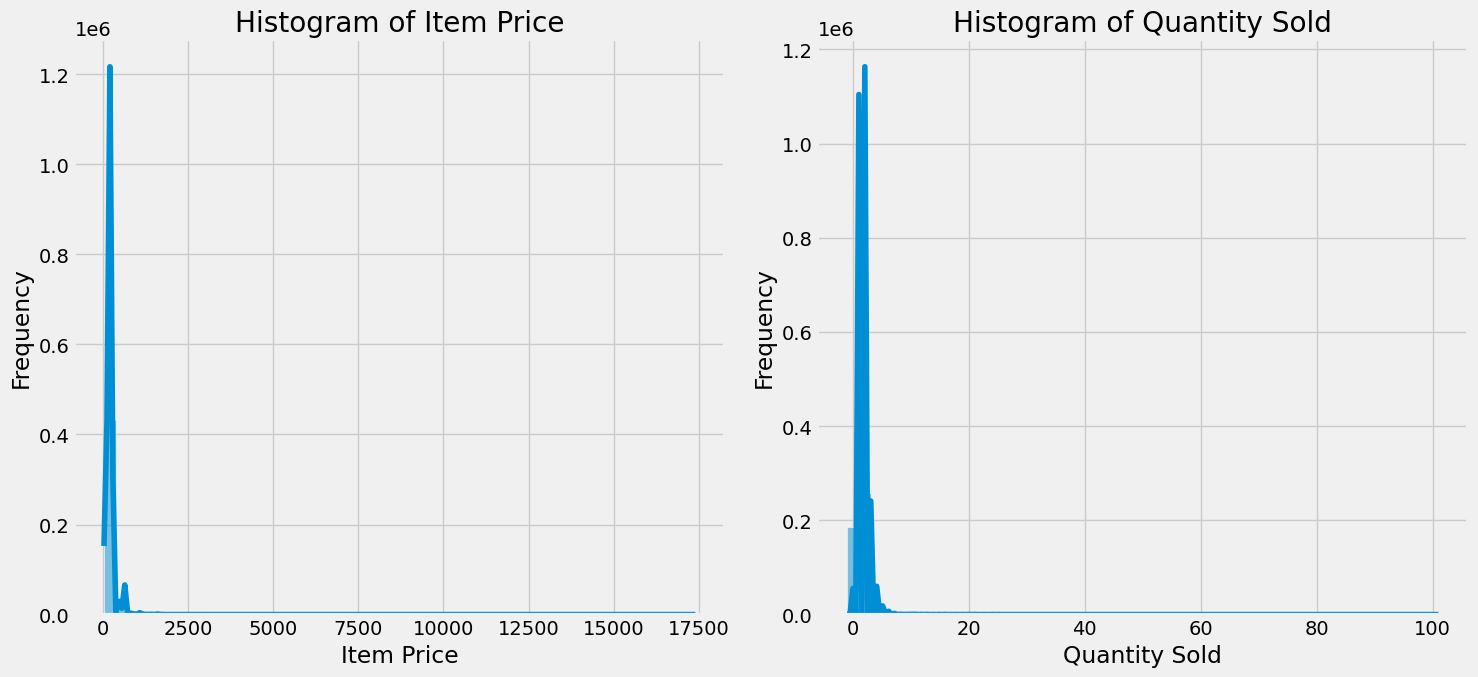

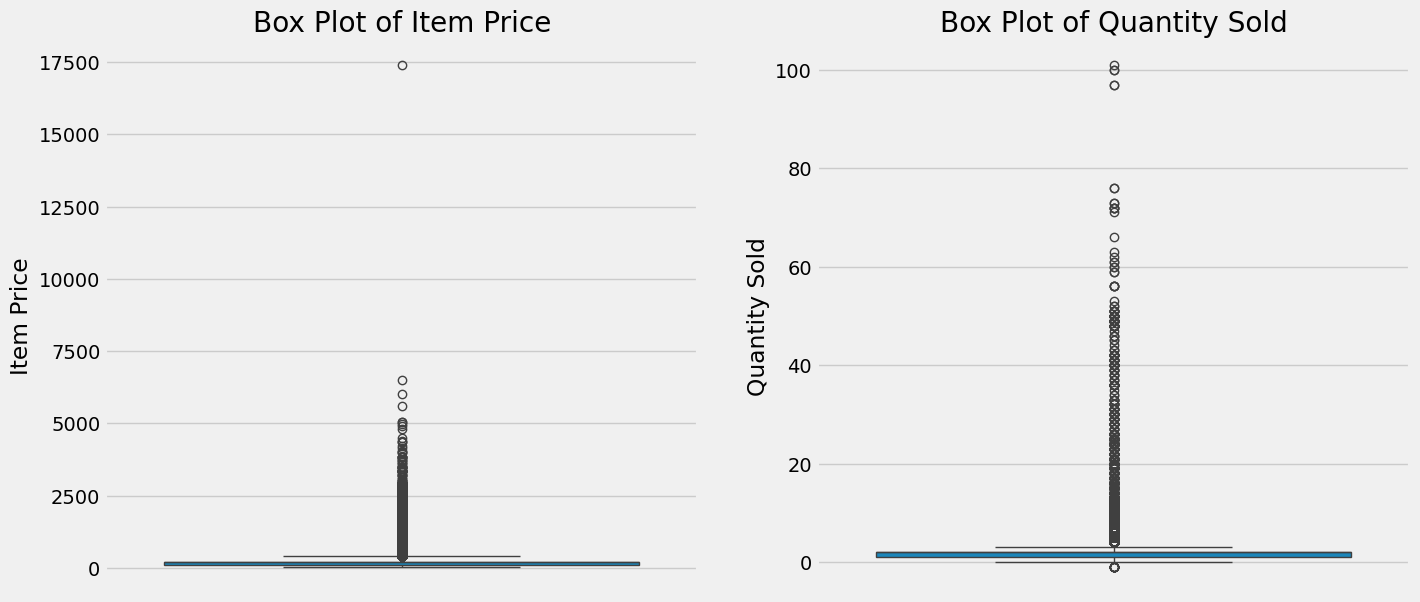

In [8]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(transData['item_price'], bins=50, kde=True)
plt.title('Histogram of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(transData['quantity_sold'], bins=50, kde=True)
plt.title('Histogram of Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Boxplot of numarical variables
plt.figure(figsize=(15,15))
plt.subplot(2,2,1)
sns.boxplot(transData['item_price'])
plt.title('Box Plot of Item Price')
plt.ylabel('Item Price')

plt.subplot(2,2,2)
sns.boxplot(transData['quantity_sold'])
plt.title('Box Plot of Quantity Sold')
plt.ylabel('Quantity Sold')
plt.show()

In [9]:
print(f'Number of qunique drinks: {transData['item_description'].nunique()}')
transData['item_description'].value_counts()

Number of qunique drinks: 37


,count
item_description,
GINGER BEER 1.5L,59864
CREAM SODA 1.5L,39608
CREAM SODA 500ML,34320
GINGER BEER 1L,26808
ORANGE BARLEY 1.5L,23180
NECTO 1.5L,21746
SODA 500ML,16802
BOTTLED DRINKING WATER 500ML,15786
SODA PET 1.5L,15652


In [10]:
unique_prices_per_item = transData.groupby('item_description')['item_price'].unique()

for item, prices in unique_prices_per_item.items():
    print(f"Item Description: {item}")
    print(f"Unique Prices: {prices}")
    print("\n")

Item Description: BOTTLED DRINKING WATER 1.5L
Unique Prices: [ 140   70  280  420  210  560  350  490  700  630  770 1890  840 2800
 1260 1400  980 1050 1750 1470 1120 2660 2520  910 2030]


Item Description: BOTTLED DRINKING WATER 500ML
Unique Prices: [  70   35  210  245  175  105  280  805  840  140  350  700 1680 1645
 1050 2310  315  560  525  420  490  385  875 1750  980 1400 1260  455
 3360  945 2520 1155 1960  770  630 1015 2030 1365  910 1820 1575 1225
 2100 2205  595 3500 1330  665 1085 1925 1610 1295 2625  735]


Item Description: CHOCOLATE MILK 180ML
Unique Prices: [ 350  140   70  210  280  700 1050  490  840  420   65  560  390]


Item Description: CREAM SODA 1.5L
Unique Prices: [ 220  660  440  880 1100 1320 1540 2200 2420 2640 1760 5060 3080 3740
 1980]


Item Description: CREAM SODA 1L
Unique Prices: [ 150  300  450  600  750 1050  900 1200 1500]


Item Description: CREAM SODA 500ML
Unique Prices: [ 100  200  300  600  400 1000  500 1100  700  800 2200 1300 2000 1200
 

Here we can see ditinct values in same type drink, this should be an error in data entering process. Therefore mode replacement for unique item of the price can be a better approch

In [11]:
def get_mode(series):
    modes = series.mode()
    if not modes.empty:
        return modes.iloc[0]
    return None

item_price_mode = transData.groupby('item_description')['item_price'].apply(get_mode).reset_index()
item_price_mode.columns = ['item_description', 'mode_item_price']

print("\nTable of Unique Item Description and Mode Item Price:")
print(item_price_mode)


Table of Unique Item Description and Mode Item Price:
                item_description  mode_item_price
0    BOTTLED DRINKING WATER 1.5L               70
1   BOTTLED DRINKING WATER 500ML               35
2           CHOCOLATE MILK 180ML              140
3                CREAM SODA 1.5L              220
4                  CREAM SODA 1L              150
5               CREAM SODA 500ML              100
6        CREAM SODA APPLE POP 1L              150
7       DRY GINGER ALE PET 500ML              160
8                 FIT O MANGO 1L              290
9              FIT O MANGO 200ML               60
10          FIT O MIXED FRUIT 1L              290
11       FIT O MIXED FRUIT 200ML               60
12               FIT O ORANGE 1L              290
13            FIT O ORANGE 200ML               60
14              GINGER BEER 1.5L              220
15                GINGER BEER 1L              150
16             GINGER BEER 400ML              100
17             GINGER BEER 500ML             

In [12]:
# Merge transData with item_price_mode to replace item_price
transData = pd.merge(transData, item_price_mode, on='item_description', how='left')

# Replace the original 'item_price' with the 'mode_item_price'
transData['item_price'] = transData['mode_item_price']

# Drop the temporary 'mode_item_price' column
transData = transData.drop(columns=['mode_item_price'])

# Display the first few rows to verify the changes
display(transData.head())

,item_description,transaction_date,invoice_id,customer_id,shop_id,item_price,quantity_sold
0,ORANGE BARLEY 1.5L,2021-12-11 00:00:00+00:00,147.0,BGXA,SHOP008,220.0,2
1,GINGER BEER 1.5L,2021-10-17 00:00:00+00:00,371.0,IA25,SHOP112,220.0,2
2,TONIC PET 500ML,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,160.0,2
3,CREAM SODA 1L,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,150.0,2
4,STRAWBERRY MILK 180ML,2021-10-23 00:00:00+00:00,1310.0,7S00,SHOP112,70.0,5


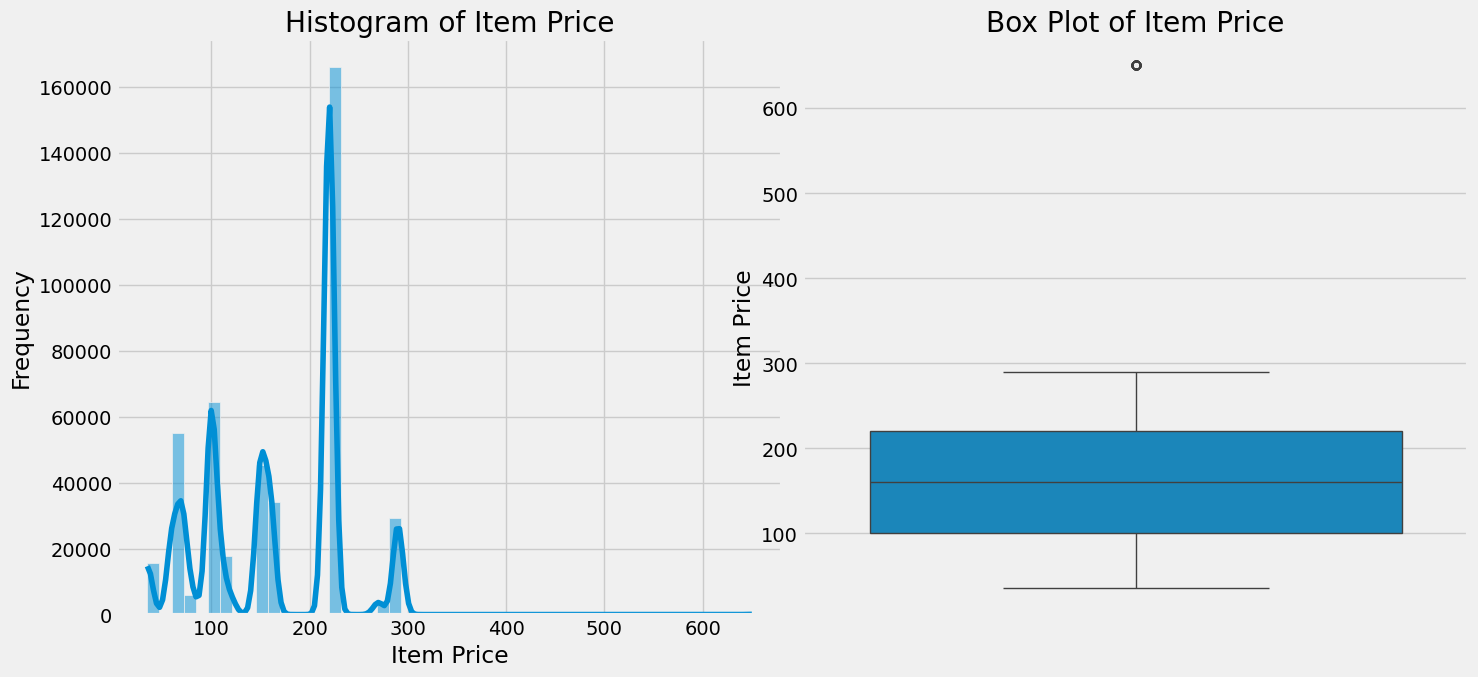

In [13]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(transData['item_price'], bins=50, kde=True)
plt.title('Histogram of Item Price')
plt.xlabel('Item Price')
plt.ylabel('Frequency')
plt.tight_layout()

plt.subplot(1,2,2)
sns.boxplot(transData['item_price'])
plt.title('Box Plot of Item Price')
plt.ylabel('Item Price')
plt.show()

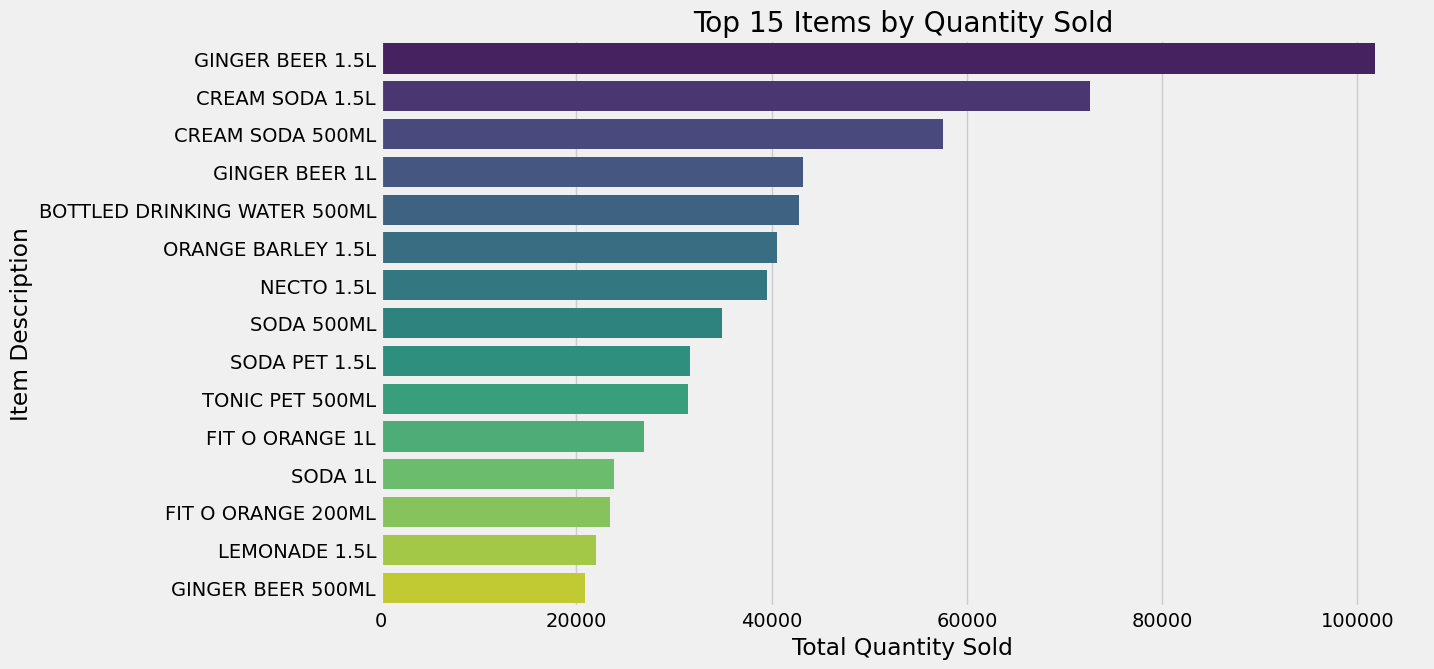

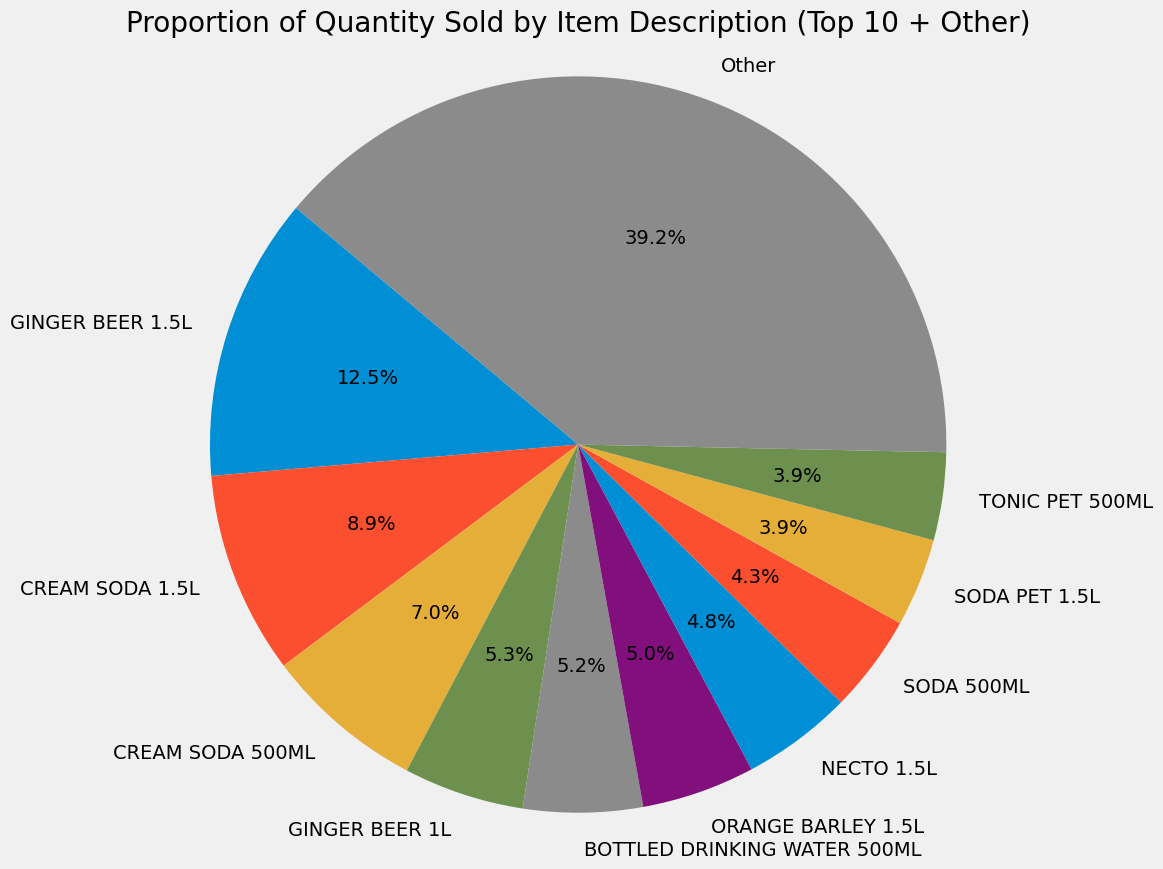

In [14]:
# Aggregate quantity_sold by item_description
item_quantity_sold = transData.groupby('item_description')['quantity_sold'].sum().reset_index()
item_quantity_sold = item_quantity_sold.sort_values(by='quantity_sold', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='quantity_sold', y='item_description', data=item_quantity_sold.head(15), hue='item_description', legend=False, palette='viridis')
plt.title('Top 15 Items by Quantity Sold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Item Description')
plt.show()

# Prepare data for pie chart (top 10 items + 'Other')
pie_data = item_quantity_sold.head(10).copy()
other_quantity = item_quantity_sold.iloc[10:]['quantity_sold'].sum()
if other_quantity > 0:
    pie_data.loc[len(pie_data)] = ['Other', other_quantity]

# Create a pie chart
plt.figure(figsize=(10, 10))
plt.pie(pie_data['quantity_sold'], labels=pie_data['item_description'], autopct='%1.1f%%', startangle=140)
plt.title('Proportion of Quantity Sold by Item Description (Top 10 + Other)')
plt.axis('equal')
plt.show()

In [15]:
transData.shape

(473974, 7)

In [16]:
# Remove rows where quantity_sold is less than or equal to 0
print(f"Shape of transData before removing invalid quantities: {transData.shape}")
transData = transData[transData['quantity_sold'] > 0]
print(f"Shape of transData after removing invalid quantities: {transData.shape}")
display(transData.head())

Shape of transData before removing invalid quantities: (473974, 7)
Shape of transData after removing invalid quantities: (465623, 7)


,item_description,transaction_date,invoice_id,customer_id,shop_id,item_price,quantity_sold
0,ORANGE BARLEY 1.5L,2021-12-11 00:00:00+00:00,147.0,BGXA,SHOP008,220.0,2
1,GINGER BEER 1.5L,2021-10-17 00:00:00+00:00,371.0,IA25,SHOP112,220.0,2
2,TONIC PET 500ML,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,160.0,2
3,CREAM SODA 1L,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,150.0,2
4,STRAWBERRY MILK 180ML,2021-10-23 00:00:00+00:00,1310.0,7S00,SHOP112,70.0,5


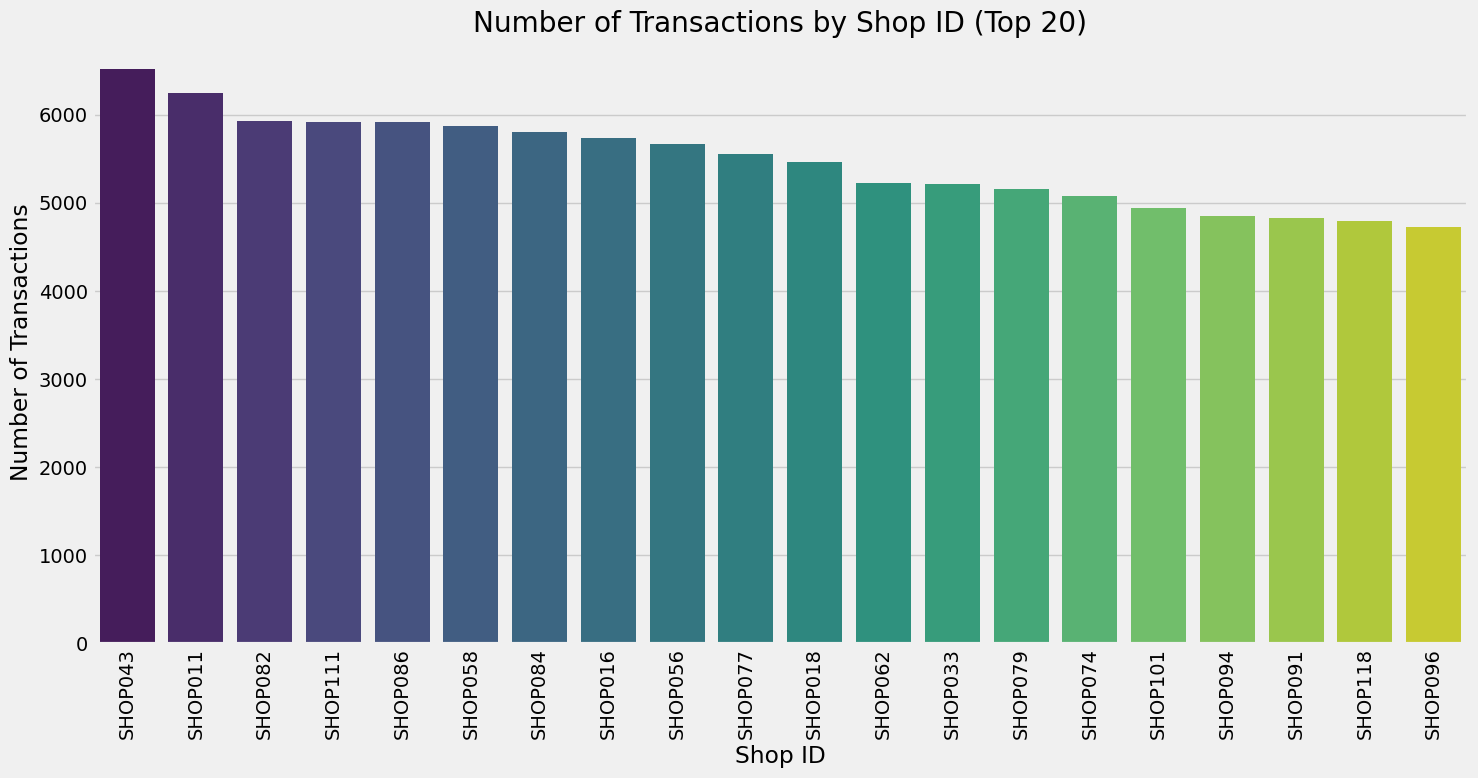

In [17]:
# Calculate the number of transactions per shop_id
transactions_by_shop = transData['shop_id'].value_counts().reset_index()
transactions_by_shop.columns = ['shop_id', 'number_of_transactions']

# Sort the results for better visualization
transactions_by_shop = transactions_by_shop.sort_values(by='number_of_transactions', ascending=False)

# Plotting the bar chart
plt.figure(figsize=(15, 8))
sns.barplot(x='shop_id', y='number_of_transactions', data=transactions_by_shop.head(20), hue='shop_id', legend=False, palette='viridis')
plt.title('Number of Transactions by Shop ID (Top 20)')
plt.xlabel('Shop ID')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
transactions_by_shop

,shop_id,number_of_transactions
0,SHOP043,6518
1,SHOP011,6251
2,SHOP082,5926
3,SHOP111,5918
4,SHOP086,5916
...,...,...
119,SHOP001,1980
120,SHOP107,1923
121,SHOP125,1838
122,SHOP047,1662


In [19]:
print(transData.isnull().sum())

item_description    35554
transaction_date        0
invoice_id           6216
customer_id             0
shop_id                 0
item_price          35554
quantity_sold           0
dtype: int64


In [20]:
print("Null counts before filling item_price:")
print(transData.isnull().sum())

median_price = transData['item_price'].median()

null_item_desc_and_price_mask = transData['item_description'].isnull()

transData.loc[null_item_desc_and_price_mask, 'item_price'] = median_price

print("\nNull counts after filling item_price where item_description was null:")
print(transData.isnull().sum())
display(transData.head())

Null counts before filling item_price:
item_description    35554
transaction_date        0
invoice_id           6216
customer_id             0
shop_id                 0
item_price          35554
quantity_sold           0
dtype: int64

Null counts after filling item_price where item_description was null:
item_description    35554
transaction_date        0
invoice_id           6216
customer_id             0
shop_id                 0
item_price              0
quantity_sold           0
dtype: int64


,item_description,transaction_date,invoice_id,customer_id,shop_id,item_price,quantity_sold
0,ORANGE BARLEY 1.5L,2021-12-11 00:00:00+00:00,147.0,BGXA,SHOP008,220.0,2
1,GINGER BEER 1.5L,2021-10-17 00:00:00+00:00,371.0,IA25,SHOP112,220.0,2
2,TONIC PET 500ML,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,160.0,2
3,CREAM SODA 1L,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,150.0,2
4,STRAWBERRY MILK 180ML,2021-10-23 00:00:00+00:00,1310.0,7S00,SHOP112,70.0,5


### Feature engineering

In [21]:
# Create the 'TotalSales' feature
transData['TotalSales'] = transData['item_price'] * transData['quantity_sold']
display(transData.head())

,item_description,transaction_date,invoice_id,customer_id,shop_id,item_price,quantity_sold,TotalSales
0,ORANGE BARLEY 1.5L,2021-12-11 00:00:00+00:00,147.0,BGXA,SHOP008,220.0,2,440.0
1,GINGER BEER 1.5L,2021-10-17 00:00:00+00:00,371.0,IA25,SHOP112,220.0,2,440.0
2,TONIC PET 500ML,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,160.0,2,320.0
3,CREAM SODA 1L,2021-12-13 00:00:00+00:00,484.0,VN7V,SHOP008,150.0,2,300.0
4,STRAWBERRY MILK 180ML,2021-10-23 00:00:00+00:00,1310.0,7S00,SHOP112,70.0,5,350.0


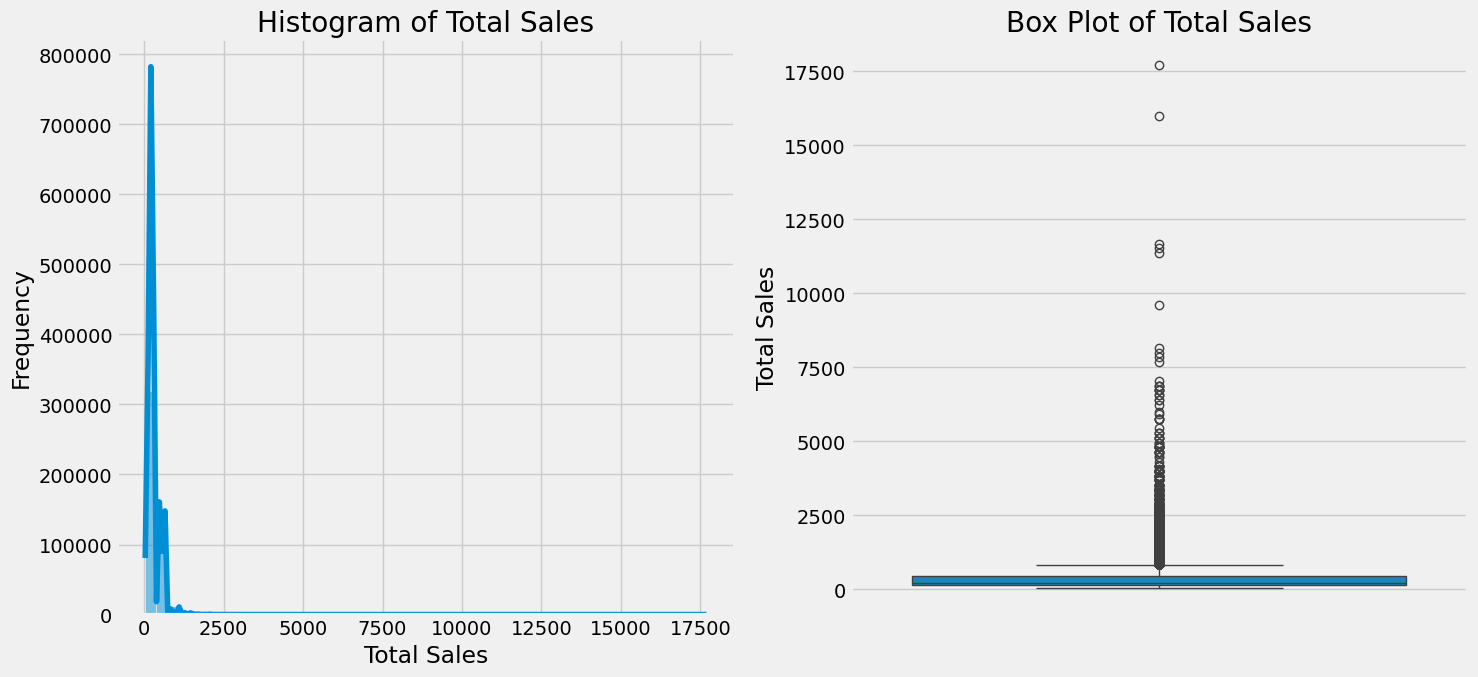

In [22]:
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
sns.histplot(transData['TotalSales'], bins=50, kde=True)
plt.title('Histogram of Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(transData['TotalSales'])
plt.title('Box Plot of Total Sales')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

In [23]:
# Aggregate sum of TotalSales per shop_id
total_sales_per_shop = transData.groupby('shop_id')['TotalSales'].sum()

# Total count of transactions per shop_id (using unique invoice_id)
total_transactions_per_shop = transData.groupby('shop_id')['invoice_id'].nunique()

# Total unique customers per shop_id
total_unique_customers_per_shop = transData.groupby('shop_id')['customer_id'].nunique()

# Total quantity_sold per shop_id
total_quantity_sold_per_shop = transData.groupby('shop_id')['quantity_sold'].sum()

# Create a new DataFrame from these aggregated series
shop_aggregated_data = pd.DataFrame({
    'TotalSalesSum': total_sales_per_shop,
    'TotalTransactions': total_transactions_per_shop,
    'UniqueCustomers': total_unique_customers_per_shop,
    'TotalQuantitySold': total_quantity_sold_per_shop
})

# Display the first few rows of the new DataFrame
display(shop_aggregated_data.head())

,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold
shop_id,,,,
SHOP001,640350.0,1514,1106,3942
SHOP002,1574840.0,3716,2546,9568
SHOP003,1108710.0,2828,2038,6959
SHOP004,1027365.0,2598,1724,6401
SHOP005,1284355.0,3143,2189,7784


In [24]:
# Merge shop_aggregated_data with StoreData to add shop_area_sq_ft and shop_profile
shop_aggregated_data = pd.merge(shop_aggregated_data, StoreData[['shop_id', 'shop_area_sq_ft', 'shop_profile']], on='shop_id', how='left')

# Display the first few rows of the updated DataFrame
display(shop_aggregated_data.head())

,shop_id,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold,shop_area_sq_ft,shop_profile
0,SHOP001,640350.0,1514,1106,3942,580,Low
1,SHOP002,1574840.0,3716,2546,9568,637,NaN
2,SHOP003,1108710.0,2828,2038,6959,810,High
3,SHOP004,1027365.0,2598,1724,6401,516,Low
4,SHOP005,1284355.0,3143,2189,7784,617,Low


In [25]:
shop_aggregated_data['sales_per_customer'] = shop_aggregated_data['TotalSalesSum'] / shop_aggregated_data['UniqueCustomers']
shop_aggregated_data['sales_per_area'] = shop_aggregated_data['TotalSalesSum'] / shop_aggregated_data['shop_area_sq_ft']
shop_aggregated_data['sales_per_transaction'] = shop_aggregated_data['TotalSalesSum'] / shop_aggregated_data['TotalTransactions']
shop_aggregated_data.head()

,shop_id,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold,shop_area_sq_ft,shop_profile,sales_per_customer,sales_per_area,sales_per_transaction
0,SHOP001,640350.0,1514,1106,3942,580,Low,578.978300,1104.051724,422.952444
1,SHOP002,1574840.0,3716,2546,9568,637,NaN,618.554595,2472.276295,423.799785
2,SHOP003,1108710.0,2828,2038,6959,810,High,544.018646,1368.777778,392.047383
3,SHOP004,1027365.0,2598,1724,6401,516,Low,595.919374,1991.017442,395.444573
4,SHOP005,1284355.0,3143,2189,7784,617,Low,586.731384,2081.612642,408.639835


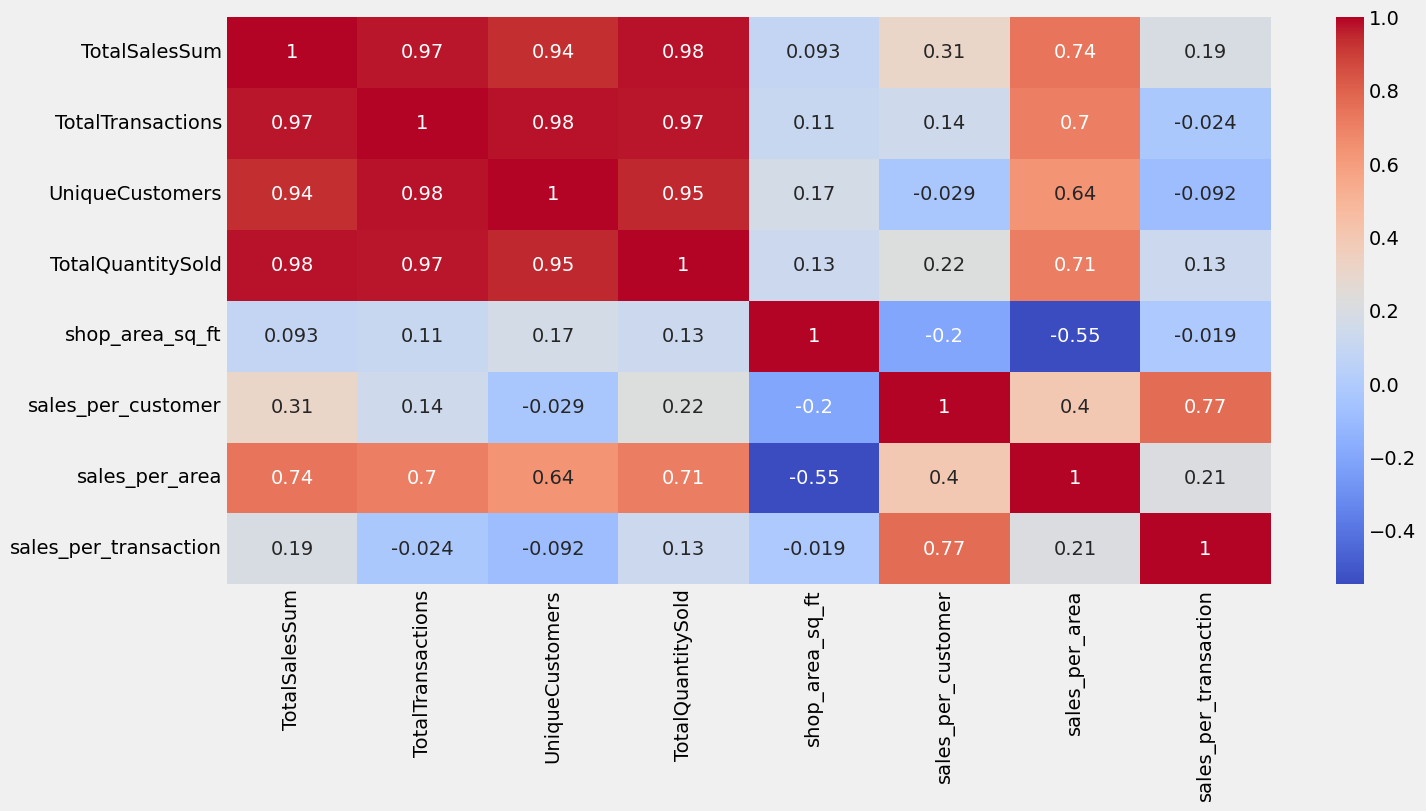

In [26]:
plt.figure(figsize=(15, 7))
sns.heatmap(shop_aggregated_data.select_dtypes(['float','int']).corr(), annot=True, cmap='coolwarm')
plt.show()

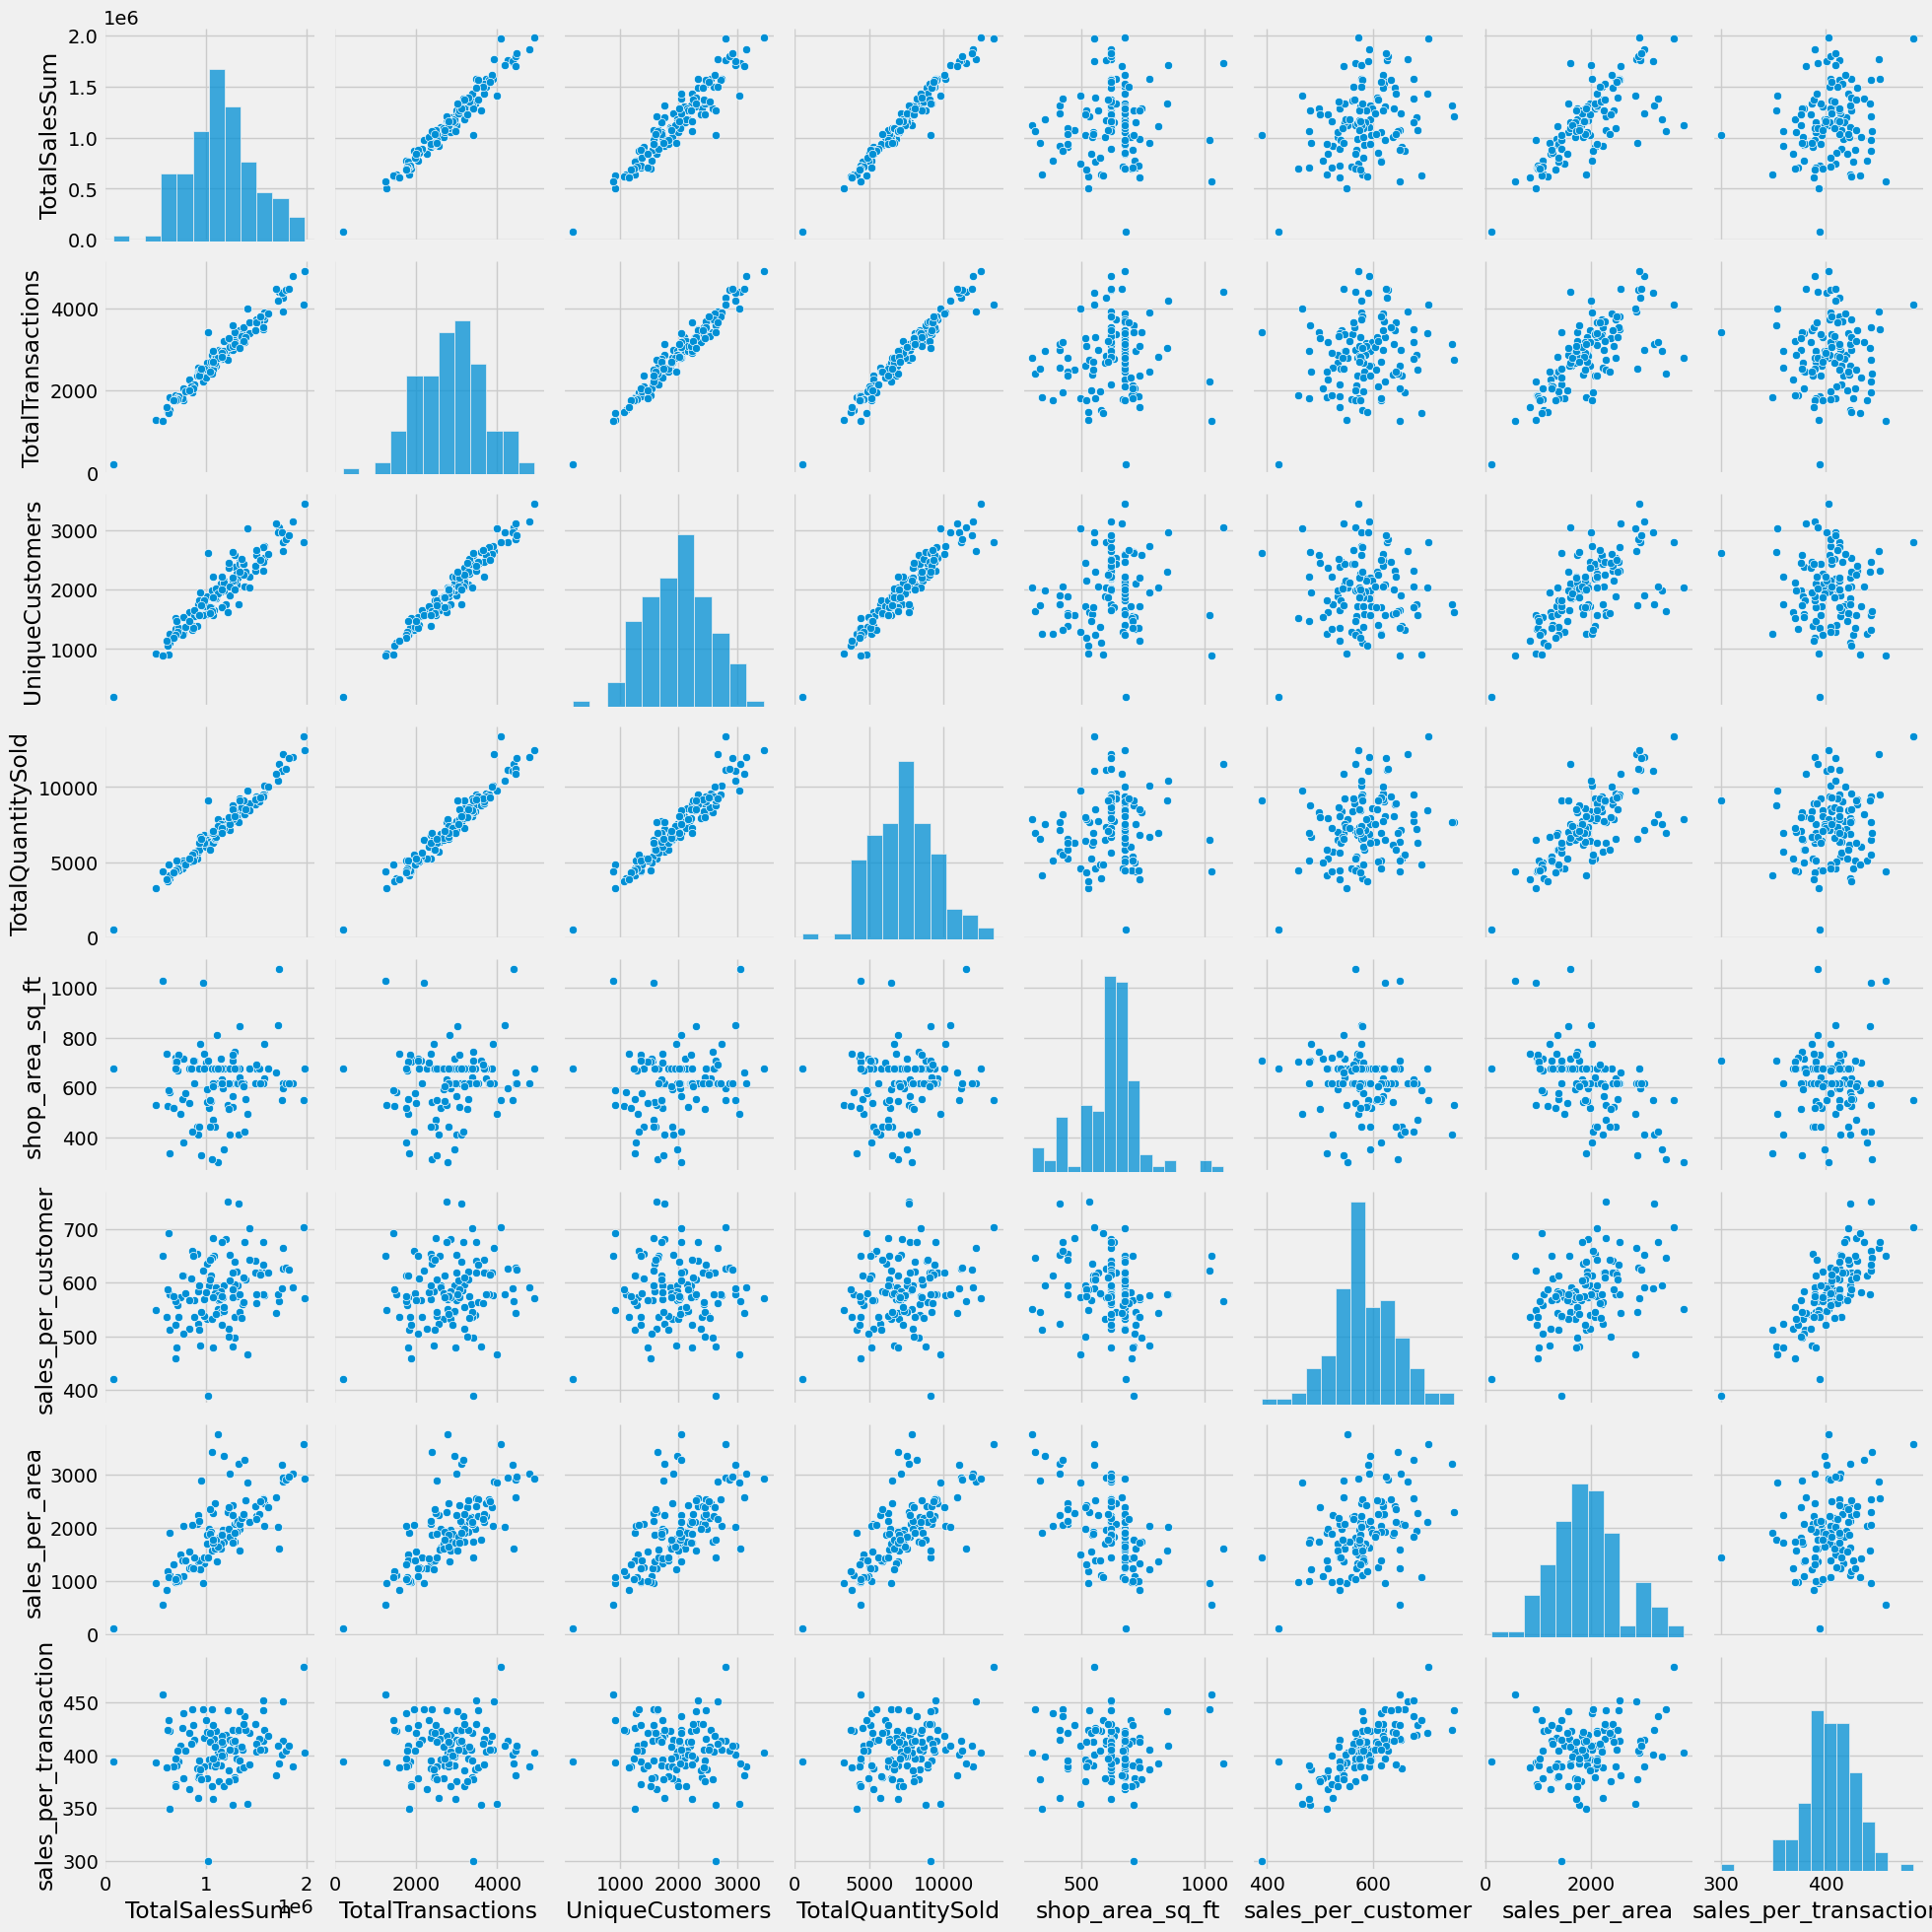

In [27]:
sns.pairplot(shop_aggregated_data)
plt.show()

## Model Buliding

In [28]:
# Identify rows where 'shop_profile' is null (these will go to the test set)
test_mask = shop_aggregated_data['shop_profile'].isnull()

# Create the test_set
test_set = shop_aggregated_data[test_mask].copy()

# Create the train_set (rows where 'shop_profile' is not null)
train_set = shop_aggregated_data[~test_mask].copy()

print(f"Shape of full shop_aggregated_data: {shop_aggregated_data.shape}")
print(f"Shape of train_set (non-null shop_profile): {train_set.shape}")
print(f"Shape of test_set (null shop_profile): {test_set.shape}")

print("\nTrain Set Head:")
display(train_set.head())

print("\nTest Set Head:")
display(test_set.head())

Shape of full shop_aggregated_data: (124, 10)
Shape of train_set (non-null shop_profile): (100, 10)
Shape of test_set (null shop_profile): (24, 10)

Train Set Head:


,shop_id,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold,shop_area_sq_ft,shop_profile,sales_per_customer,sales_per_area,sales_per_transaction
0,SHOP001,640350.0,1514,1106,3942,580,Low,578.978300,1104.051724,422.952444
2,SHOP003,1108710.0,2828,2038,6959,810,High,544.018646,1368.777778,392.047383
3,SHOP004,1027365.0,2598,1724,6401,516,Low,595.919374,1991.017442,395.444573
4,SHOP005,1284355.0,3143,2189,7784,617,Low,586.731384,2081.612642,408.639835
5,SHOP006,1150160.0,2845,2013,7195,676,Low,571.366120,1701.420118,404.274165



Test Set Head:


,shop_id,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold,shop_area_sq_ft,shop_profile,sales_per_customer,sales_per_area,sales_per_transaction
1,SHOP002,1574840.0,3716,2546,9568,637,NaN,618.554595,2472.276295,423.799785
18,SHOP019,1240390.0,2995,1905,7173,411,NaN,651.123360,3017.980535,414.153589
22,SHOP023,1311655.0,3101,2206,7946,617,NaN,594.585222,2125.858995,422.978072
23,SHOP024,838630.0,2277,1628,5274,676,NaN,515.128993,1240.576923,368.304787
28,SHOP029,1167790.0,2842,2035,7352,597,NaN,573.852580,1956.097152,410.904293


In [29]:
# Merge test_set with EvaluationData to get the shop_profile
test_set = pd.merge(test_set, EvaluationData[['shop_id', 'shop_profile']], on='shop_id', how='left', suffixes=('_original', '_evaluation'))

# The shop_profile_evaluation column now contains the profiles from EvaluationData
# We can replace the original (NaN) shop_profile with these values
test_set['shop_profile'] = test_set['shop_profile_evaluation']

# Drop the temporary column and the original NaN column if it exists and is fully NaN
test_set = test_set.drop(columns=['shop_profile_evaluation'])
test_set = test_set.drop(columns=['shop_profile_original'])

# Display the first few rows

print("Test Set Head after updating shop_profile from EvaluationData:")
display(test_set.head())

Test Set Head after updating shop_profile from EvaluationData:


,shop_id,TotalSalesSum,TotalTransactions,UniqueCustomers,TotalQuantitySold,shop_area_sq_ft,sales_per_customer,sales_per_area,sales_per_transaction,shop_profile
0,SHOP002,1574840.0,3716,2546,9568,637,618.554595,2472.276295,423.799785,Low
1,SHOP019,1240390.0,2995,1905,7173,411,651.123360,3017.980535,414.153589,Low
2,SHOP023,1311655.0,3101,2206,7946,617,594.585222,2125.858995,422.978072,Low
3,SHOP024,838630.0,2277,1628,5274,676,515.128993,1240.576923,368.304787,Low
4,SHOP029,1167790.0,2842,2035,7352,597,573.852580,1956.097152,410.904293,High


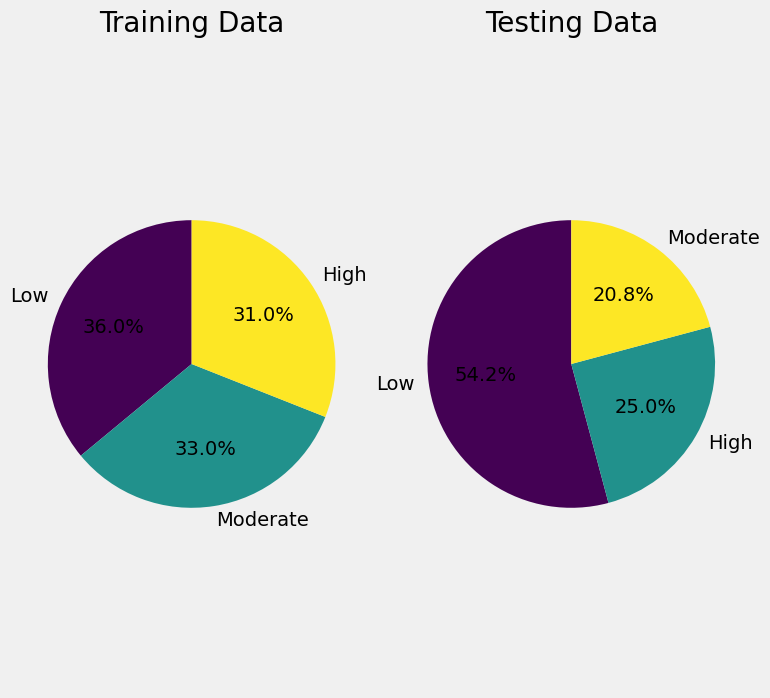

In [30]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
train_set['shop_profile'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Training Data')
plt.ylabel('')
plt.axis('equal')

plt.subplot(1, 2, 2)
test_set['shop_profile'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='viridis')
plt.title('Testing Data')
plt.ylabel('')
plt.axis('equal')
plt.show()



In [31]:
train_set.set_index('shop_id', inplace=True)
test_set.set_index('shop_id', inplace=True)

In [32]:
X_train = train_set.drop(columns=['shop_profile'])
y_train = train_set['shop_profile']

X_test = test_set.drop(columns=['shop_profile'])
y_test = test_set['shop_profile']

In [33]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((100, 8), (100,), (24, 8), (24,))

### Decision Tree Model

In [34]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_model(model, X_train, y_train, X_test, y_test):
  print(classification_report(y_test, model.predict(X_test)))
  plt.figure(figsize=(4, 3))
  labels = ['Low', 'High','Modarate']
  sns.heatmap(confusion_matrix(y_test, model.predict(X_test)), annot=True, fmt='d', cmap='Blues',xticklabels = labels,yticklabels = labels )
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted Labels')
  plt.ylabel('True Labels')
  plt.show()


              precision    recall  f1-score   support

        High       0.00      0.00      0.00         6
         Low       0.64      0.54      0.58        13
    Moderate       0.25      0.40      0.31         5

    accuracy                           0.38        24
   macro avg       0.30      0.31      0.30        24
weighted avg       0.40      0.38      0.38        24



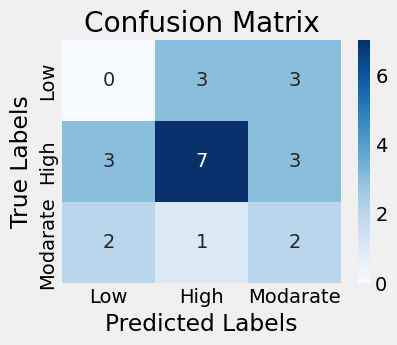

In [35]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV


DT_model = DecisionTreeClassifier()
DT_model.fit(X_train, y_train)
y_pred = DT_model.predict(X_test)

evaluate_model(DT_model, X_train, y_train, X_test, y_test)


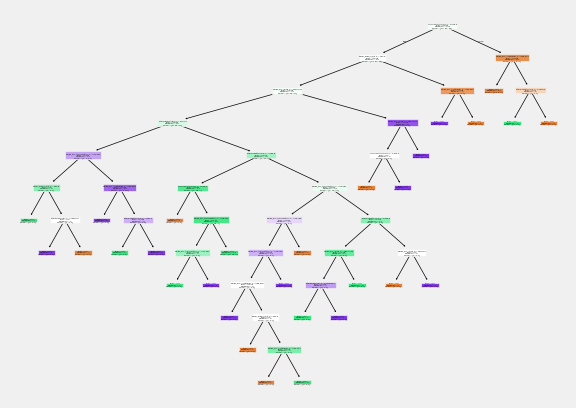

In [36]:
plot_tree(DT_model, filled=True, feature_names=X_train.columns)
plt.show()

In [37]:
param_grid = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'max_depth': [None, 10, 20, 30, 40, 50], 'min_samples_split': [2, 5, 10, 15], 'min_samples_leaf': [1, 2, 4, 8], 'criterion': ['gini', 'entropy']}


In [38]:
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy found: ", grid_search.best_score_)

Best parameters found:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best accuracy found:  0.6


Evaluation of the best model found by GridSearchCV:
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
              precision    recall  f1-score   support

        High       0.38      0.50      0.43         6
         Low       0.71      0.38      0.50        13
    Moderate       0.33      0.60      0.43         5

    accuracy                           0.46        24
   macro avg       0.47      0.49      0.45        24
weighted avg       0.55      0.46      0.47        24



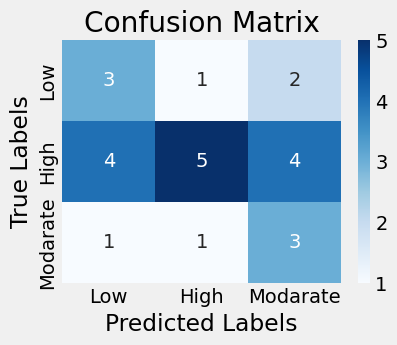

In [39]:
best_dt_model = grid_search.best_estimator_
y_pred_best = best_dt_model.predict(X_test)

print("Evaluation of the best model found by GridSearchCV:")
print(f"Best Parameters: {grid_search.best_params_}")
evaluate_model(best_dt_model, X_train, y_train, X_test, y_test)

              precision    recall  f1-score   support

        High       0.67      0.33      0.44         6
         Low       0.64      0.54      0.58        13
    Moderate       0.30      0.60      0.40         5

    accuracy                           0.50        24
   macro avg       0.53      0.49      0.48        24
weighted avg       0.57      0.50      0.51        24



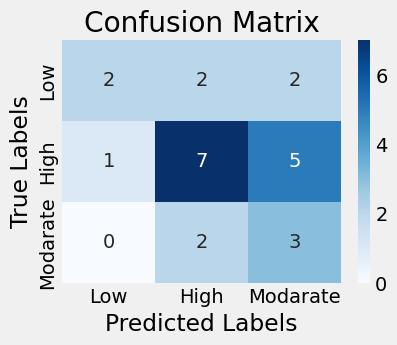

In [40]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
evaluate_model(rf_model, X_train, y_train, X_test, y_test)

In [41]:
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("Parameter grid defined for RandomForestClassifier:")
print(param_grid)

Parameter grid defined for RandomForestClassifier:
{'n_estimators': [50, 100, 150], 'max_depth': [None, 10, 20, 30], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy']}


In [42]:
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print("Best parameters found for RandomForestClassifier: ", grid_search_rf.best_params_)
print("Best accuracy found for RandomForestClassifier: ", grid_search_rf.best_score_)

Best parameters found for RandomForestClassifier:  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
Best accuracy found for RandomForestClassifier:  0.6300000000000001


Evaluation of the best RandomForestClassifier model found by GridSearchCV:
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 150}
              precision    recall  f1-score   support

        High       0.40      0.33      0.36         6
         Low       0.62      0.38      0.48        13
    Moderate       0.36      0.80      0.50         5

    accuracy                           0.46        24
   macro avg       0.46      0.51      0.45        24
weighted avg       0.51      0.46      0.45        24



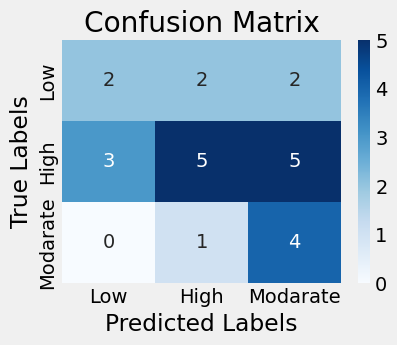

In [43]:
best_rf_model = grid_search_rf.best_estimator_
y_pred_rf_best = best_rf_model.predict(X_test)

print("Evaluation of the best RandomForestClassifier model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_rf.best_params_}")
evaluate_model(best_rf_model, X_train, y_train, X_test, y_test)

In [44]:
print(classification_report(y_train,best_rf_model.predict(X_train)))

              precision    recall  f1-score   support

        High       0.93      0.87      0.90        31
         Low       0.82      0.92      0.87        36
    Moderate       0.94      0.88      0.91        33

    accuracy                           0.89       100
   macro avg       0.90      0.89      0.89       100
weighted avg       0.89      0.89      0.89       100



In [45]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

print("LabelEncoder and StandardScaler imported.")

LabelEncoder and StandardScaler imported.


In [46]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Target variables encoded and features scaled successfully.")
print(f"Original y_train shape: {y_train.shape}, Encoded y_train shape: {y_train_encoded.shape}")
print(f"Original X_train shape: {X_train.shape}, Scaled X_train shape: {X_train_scaled.shape}")

Target variables encoded and features scaled successfully.
Original y_train shape: (100,), Encoded y_train shape: (100,)
Original X_train shape: (100, 8), Scaled X_train shape: (100, 8)


In [47]:
from sklearn.linear_model import LogisticRegression

# Define parameter grid for Lasso (L1) Logistic Regression
param_grid_lasso = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'], # 'liblinear' and 'saga' support L1 penalty
    'penalty': ['l1']
}

# Instantiate GridSearchCV for Lasso Logistic Regression
grid_search_lasso = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000), # Increased max_iter for convergence
    param_grid_lasso,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the scaled training data
grid_search_lasso.fit(X_train_scaled, y_train_encoded)

print("Best parameters for Lasso Logistic Regression:", grid_search_lasso.best_params_)
print("Best accuracy for Lasso Logistic Regression:", grid_search_lasso.best_score_)

Best parameters for Lasso Logistic Regression: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best accuracy for Lasso Logistic Regression: 0.6900000000000001


In [48]:
import pandas as pd

# Get the best Lasso model
best_lasso_model = grid_search_lasso.best_estimator_

# Get the coefficients (feature importances)
lasso_coefficients = best_lasso_model.coef_[0]

# Get the feature names from X_train (before scaling)
feature_names = X_train.columns

# Create a DataFrame for better visualization
feature_importance_lasso = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lasso_coefficients
})

# Sort by absolute coefficient value to see the most influential features
feature_importance_lasso['Absolute_Coefficient'] = abs(feature_importance_lasso['Coefficient'])
feature_importance_lasso = feature_importance_lasso.sort_values(by='Absolute_Coefficient', ascending=False)

print("Feature Importance for the Best Lasso Logistic Regression Model:")
display(feature_importance_lasso)

Feature Importance for the Best Lasso Logistic Regression Model:


,Feature,Coefficient,Absolute_Coefficient
0,TotalSalesSum,-6.543202,6.543202
3,TotalQuantitySold,3.978015,3.978015
2,UniqueCustomers,3.436902,3.436902
4,shop_area_sq_ft,1.795629,1.795629
6,sales_per_area,1.079474,1.079474
7,sales_per_transaction,0.777038,0.777038
1,TotalTransactions,0.000000,0.000000
5,sales_per_customer,0.000000,0.000000


Evaluation of the best Lasso Logistic Regression model found by GridSearchCV:
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



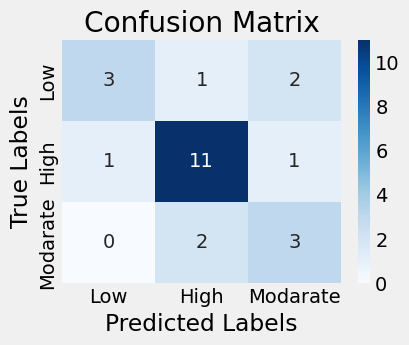

In [49]:
best_lasso_model = grid_search_lasso.best_estimator_

# Inverse transform y_test_encoded back to original string labels for evaluation
y_test_original_labels = label_encoder.inverse_transform(y_test_encoded)

# Create a custom predictor class to handle inverse transformation of predictions within evaluate_model
class CustomPredictor:
    def __init__(self, original_model, label_encoder):
        self.original_model = original_model
        self.label_encoder = label_encoder

    def predict(self, X):
        encoded_predictions = self.original_model.predict(X)
        return self.label_encoder.inverse_transform(encoded_predictions)

# Create a custom predictor that wraps the best Lasso model
custom_lasso_predictor = CustomPredictor(best_lasso_model, label_encoder)

print("Evaluation of the best Lasso Logistic Regression model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_lasso.best_params_}")

# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_lasso_predictor, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

Best parameters for Ridge Logistic Regression: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best accuracy for Ridge Logistic Regression: 0.68

Evaluation of the best Ridge Logistic Regression model found by GridSearchCV:
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



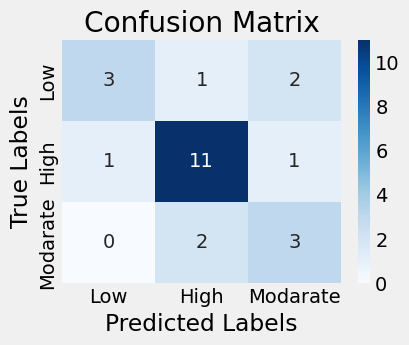

In [50]:
param_grid_ridge = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

grid_search_ridge = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_ridge,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_ridge.fit(X_train_scaled, y_train_encoded)

print("Best parameters for Ridge Logistic Regression:", grid_search_ridge.best_params_)
print("Best accuracy for Ridge Logistic Regression:", grid_search_ridge.best_score_)

best_ridge_model = grid_search_ridge.best_estimator_

custom_ridge_predictor = CustomPredictor(best_ridge_model, label_encoder)

print("\nEvaluation of the best Ridge Logistic Regression model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_ridge.best_params_}")

evaluate_model(custom_ridge_predictor, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [51]:
lasso_selected_features = feature_importance_lasso[feature_importance_lasso['Coefficient'] != 0]['Feature'].tolist()

print("Lasso Selected Features:")
print(lasso_selected_features)

Lasso Selected Features:
['TotalSalesSum', 'TotalQuantitySold', 'UniqueCustomers', 'shop_area_sq_ft', 'sales_per_area', 'sales_per_transaction']


In [52]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

X_train_selected = X_train_df[lasso_selected_features]
X_test_selected = X_test_df[lasso_selected_features]

print("Shape of X_train_selected:", X_train_selected.shape)
print("Shape of X_test_selected:", X_test_selected.shape)

display(X_train_selected.head())
display(X_test_selected.head())

Shape of X_train_selected: (100, 6)
Shape of X_test_selected: (24, 6)


,TotalSalesSum,TotalQuantitySold,UniqueCustomers,shop_area_sq_ft,sales_per_area,sales_per_transaction
shop_id,,,,,,
SHOP001,-1.527178,-1.564971,-1.585491,-0.376229,-1.276648,0.776070
SHOP003,-0.175126,-0.218221,0.035765,1.415710,-0.867348,-0.443671
SHOP004,-0.409951,-0.467305,-0.510452,-0.874856,0.094712,-0.309593
SHOP005,0.331923,0.150049,0.298436,-0.087961,0.234783,0.211189
SHOP006,-0.055468,-0.112873,-0.007724,0.371710,-0.353042,0.038888


,TotalSalesSum,TotalQuantitySold,UniqueCustomers,shop_area_sq_ft,sales_per_area,sales_per_transaction
shop_id,,,,,,
SHOP002,1.170490,0.946404,0.919454,0.067860,0.838798,0.809512
SHOP019,0.205006,-0.122694,-0.195594,-1.692915,1.682525,0.428803
SHOP023,0.410732,0.222363,0.328009,-0.087961,0.303194,0.777081
SHOP024,-0.954787,-0.970383,-0.677449,0.371710,-1.065563,-1.380728
SHOP029,-0.004575,-0.042791,0.030546,-0.243782,0.040721,0.300561


Refitting Decision Tree model with Lasso selected features...
Best parameters found for Decision Tree (selected features):  {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 15}
Best accuracy found for Decision Tree (selected features):  0.6199999999999999

Evaluation of the best Decision Tree model with selected features:
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 15}
              precision    recall  f1-score   support

        High       0.40      0.33      0.36         6
         Low       0.55      0.46      0.50        13
    Moderate       0.38      0.60      0.46         5

    accuracy                           0.46        24
   macro avg       0.44      0.46      0.44        24
weighted avg       0.47      0.46      0.46        24



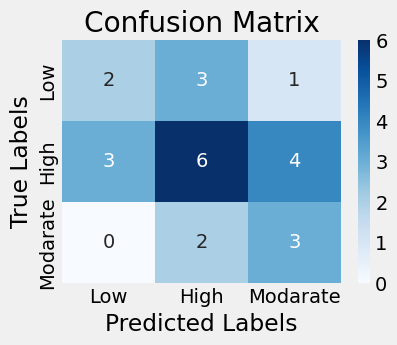

In [53]:
print("Refitting Decision Tree model with Lasso selected features...")

# Reuse the param_grid defined for Decision Tree
param_grid_dt = {
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

# Instantiate GridSearchCV for Decision Tree with selected features
grid_search_dt_selected = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the selected training data
grid_search_dt_selected.fit(X_train_selected, y_train_encoded)

print("Best parameters found for Decision Tree (selected features): ", grid_search_dt_selected.best_params_)
print("Best accuracy found for Decision Tree (selected features): ", grid_search_dt_selected.best_score_)

# Evaluate the best Decision Tree model on the selected test data
best_dt_model_selected = grid_search_dt_selected.best_estimator_

# Create a custom predictor that wraps the best Decision Tree model
custom_dt_predictor_selected = CustomPredictor(best_dt_model_selected, label_encoder)

print("\nEvaluation of the best Decision Tree model with selected features:")
print(f"Best Parameters: {grid_search_dt_selected.best_params_}")
evaluate_model(custom_dt_predictor_selected, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)


Refitting Random Forest model with Lasso selected features...
Best parameters found for Random Forest (selected features):  {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best accuracy found for Random Forest (selected features):  0.62

Evaluation of the best Random Forest model with selected features:
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
              precision    recall  f1-score   support

        High       0.50      0.33      0.40         6
         Low       0.58      0.54      0.56        13
    Moderate       0.25      0.40      0.31         5

    accuracy                           0.46        24
   macro avg       0.44      0.42      0.42        24
weighted avg       0.49      0.46      0.47        24



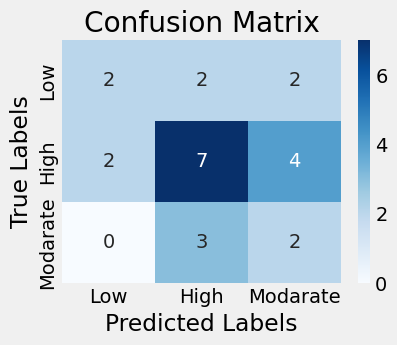

In [54]:
print("Refitting Random Forest model with Lasso selected features...")

# Reuse the param_grid defined for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Instantiate GridSearchCV for Random Forest with selected features
grid_search_rf_selected = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the selected training data
grid_search_rf_selected.fit(X_train_selected, y_train_encoded)

print("Best parameters found for Random Forest (selected features): ", grid_search_rf_selected.best_params_)
print("Best accuracy found for Random Forest (selected features): ", grid_search_rf_selected.best_score_)

# Evaluate the best Random Forest model on the selected test data
best_rf_model_selected = grid_search_rf_selected.best_estimator_

# Create a custom predictor that wraps the best Random Forest model
custom_rf_predictor_selected = CustomPredictor(best_rf_model_selected, label_encoder)

print("\nEvaluation of the best Random Forest model with selected features:")
print(f"Best Parameters: {grid_search_rf_selected.best_params_}")
evaluate_model(custom_rf_predictor_selected, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)


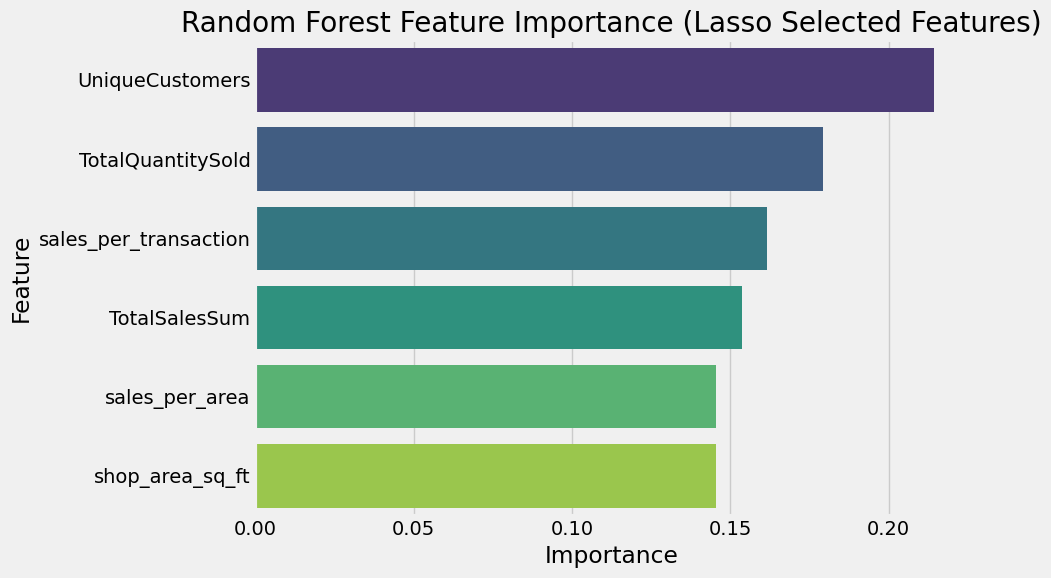

In [55]:
# Get feature importances from the best refitted Random Forest model
rf_feature_importances = best_rf_model_selected.feature_importances_

# Get the names of the selected features
selected_feature_names = X_train_selected.columns

# Create a DataFrame for better visualization
feature_importance_df_rf = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': rf_feature_importances
})

# Sort by importance
feature_importance_df_rf = feature_importance_df_rf.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf, hue='Feature', legend=False, palette='viridis')
plt.title('Random Forest Feature Importance (Lasso Selected Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [56]:
from sklearn.ensemble import ExtraTreesClassifier

ExtraTreesClassifier imported.


In [57]:
etc_model = ExtraTreesClassifier(random_state=42)
etc_model.fit(X_train_selected, y_train_encoded)

ExtraTreesClassifier model initialized and trained successfully.


Evaluation of the ExtraTreesClassifier model:
              precision    recall  f1-score   support

        High       0.67      0.33      0.44         6
         Low       0.54      0.54      0.54        13
    Moderate       0.25      0.40      0.31         5

    accuracy                           0.46        24
   macro avg       0.49      0.42      0.43        24
weighted avg       0.51      0.46      0.47        24



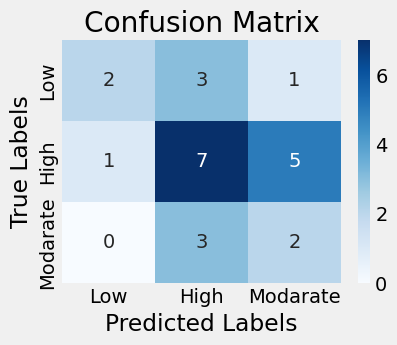

In [58]:
y_pred_etc = etc_model.predict(X_test_selected)

# Create a custom predictor that wraps the best ExtraTreesClassifier model
custom_etc_predictor = CustomPredictor(etc_model, label_encoder)

print("Evaluation of the ExtraTreesClassifier model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_etc_predictor, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [59]:
param_grid_etc = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 10, 20, 30, 40],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

print("Parameter grid defined for ExtraTreesClassifier:")
print(param_grid_etc)

Parameter grid defined for ExtraTreesClassifier:
{'n_estimators': [50, 100, 150, 200], 'max_depth': [None, 10, 20, 30, 40], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy']}


In [60]:
grid_search_etc = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    param_grid_etc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_etc.fit(X_train_selected, y_train_encoded)

print("Best parameters found for ExtraTreesClassifier: ", grid_search_etc.best_params_)
print("Best accuracy found for ExtraTreesClassifier: ", grid_search_etc.best_score_)

Best parameters found for ExtraTreesClassifier:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best accuracy found for ExtraTreesClassifier:  0.68



Evaluation of the best ExtraTreesClassifier model found by GridSearchCV:
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
              precision    recall  f1-score   support

        High       0.33      0.17      0.22         6
         Low       0.50      0.54      0.52        13
    Moderate       0.29      0.40      0.33         5

    accuracy                           0.42        24
   macro avg       0.37      0.37      0.36        24
weighted avg       0.41      0.42      0.41        24



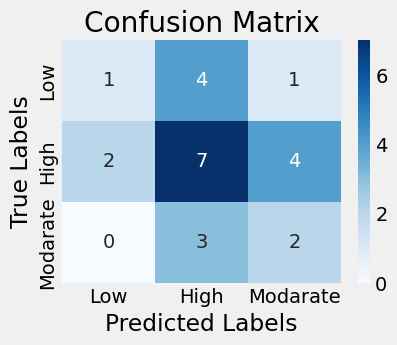

In [61]:
best_etc_model = grid_search_etc.best_estimator_

# Create a custom predictor that wraps the best ExtraTreesClassifier model
custom_etc_predictor_tuned = CustomPredictor(best_etc_model, label_encoder)

print("\nEvaluation of the best ExtraTreesClassifier model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_etc.best_params_}")
evaluate_model(custom_etc_predictor_tuned, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [62]:
from xgboost import XGBClassifier

XGBClassifier imported.


In [63]:
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train_selected, y_train_encoded)

XGBClassifier model initialized and trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [13:06:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [64]:
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_selected, y_train_encoded)

XGBClassifier model initialized and trained successfully.


Evaluation of the XGBClassifier model:
              precision    recall  f1-score   support

        High       0.29      0.33      0.31         6
         Low       0.73      0.62      0.67        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.54        24
   macro avg       0.50      0.52      0.51        24
weighted avg       0.57      0.54      0.55        24



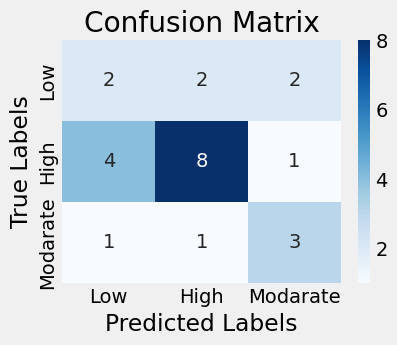

In [65]:
y_pred_xgb = xgb_model.predict(X_test_selected)

# Create a custom predictor that wraps the XGBClassifier model
custom_xgb_predictor = CustomPredictor(xgb_model, label_encoder)

print("Evaluation of the XGBClassifier model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_xgb_predictor, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [66]:
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

print("Parameter grid defined for XGBClassifier:")
print(param_grid_xgb)

Parameter grid defined for XGBClassifier:
{'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'gamma': [0, 0.1, 0.2]}


In [67]:
grid_search_xgb = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_xgb.fit(X_train_selected, y_train_encoded)

print("Best parameters found for XGBClassifier: ", grid_search_xgb.best_params_)
print("Best accuracy found for XGBClassifier: ", grid_search_xgb.best_score_)

Best parameters found for XGBClassifier:  {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
Best accuracy found for XGBClassifier:  0.6799999999999999



Evaluation of the best XGBClassifier model found by GridSearchCV:
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 50, 'subsample': 0.8}
              precision    recall  f1-score   support

        High       0.33      0.33      0.33         6
         Low       0.70      0.54      0.61        13
    Moderate       0.38      0.60      0.46         5

    accuracy                           0.50        24
   macro avg       0.47      0.49      0.47        24
weighted avg       0.54      0.50      0.51        24



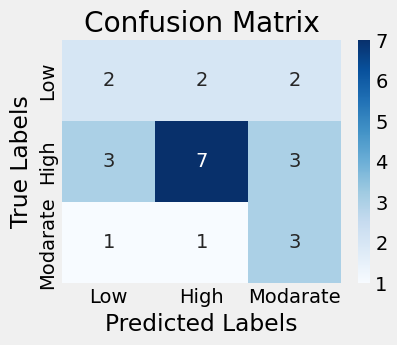

In [68]:
best_xgb_model = grid_search_xgb.best_estimator_

# Create a custom predictor that wraps the best XGBClassifier model
custom_xgb_predictor_tuned = CustomPredictor(best_xgb_model, label_encoder)

print("\nEvaluation of the best XGBClassifier model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_xgb.best_params_}")
evaluate_model(custom_xgb_predictor_tuned, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

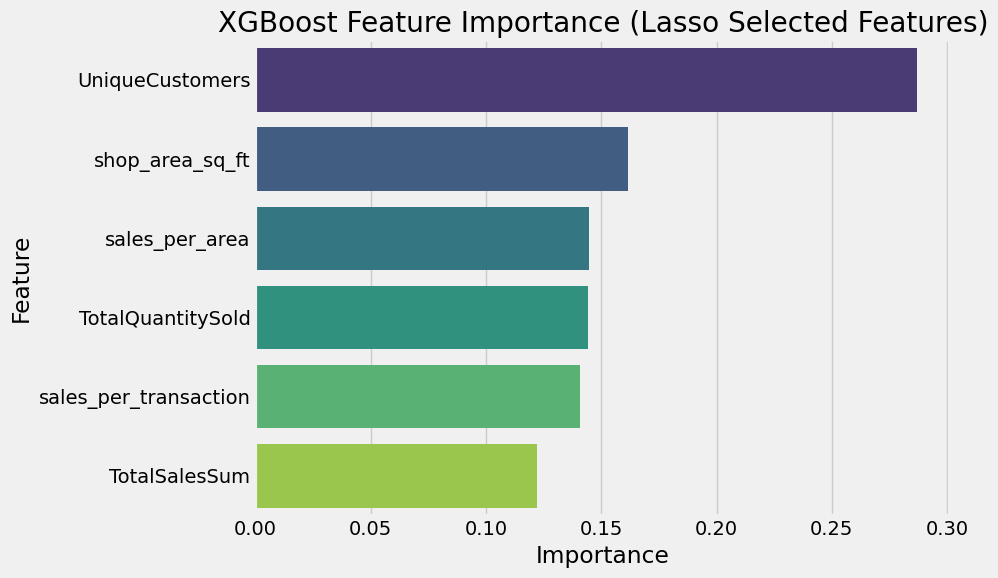

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best tuned XGBoost model
xgb_feature_importances = best_xgb_model.feature_importances_

# Get the names of the selected features
selected_feature_names = X_train_selected.columns

# Create a DataFrame for better visualization
feature_importance_df_xgb = pd.DataFrame({
    'Feature': selected_feature_names,
    'Importance': xgb_feature_importances
})

# Sort by importance
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)

# Plotting the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_xgb, hue='Feature', legend=False, palette='viridis')
plt.title('XGBoost Feature Importance (Lasso Selected Features)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [70]:
from sklearn.ensemble import AdaBoostClassifier

AdaBoostClassifier imported.


In [71]:
adaboost_model = AdaBoostClassifier(estimator=best_rf_model_selected, random_state=42)
adaboost_model.fit(X_train_selected, y_train_encoded)

AdaBoostClassifier model initialized and trained successfully with best_rf_model_selected as base estimator.


Evaluation of the AdaBoostClassifier model:
              precision    recall  f1-score   support

        High       0.40      0.33      0.36         6
         Low       0.58      0.54      0.56        13
    Moderate       0.29      0.40      0.33         5

    accuracy                           0.46        24
   macro avg       0.42      0.42      0.42        24
weighted avg       0.48      0.46      0.46        24



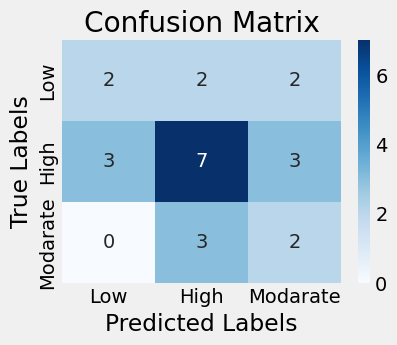

In [72]:
y_pred_ada = adaboost_model.predict(X_test_selected)

# Create a custom predictor that wraps the AdaBoostClassifier model
custom_ada_predictor = CustomPredictor(adaboost_model, label_encoder)

print("Evaluation of the AdaBoostClassifier model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_ada_predictor, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [73]:
param_grid_ada = {
    'n_estimators': [50, 100, 150, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

print("Parameter grid defined for AdaBoostClassifier:")
print(param_grid_ada)

Parameter grid defined for AdaBoostClassifier:
{'n_estimators': [50, 100, 150, 200], 'learning_rate': [0.01, 0.1, 0.5, 1.0]}


In [74]:
from sklearn.model_selection import GridSearchCV

grid_search_ada = GridSearchCV(
    AdaBoostClassifier(estimator=best_rf_model_selected, random_state=42),
    param_grid_ada,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_ada.fit(X_train_selected, y_train_encoded)

print("Best parameters found for AdaBoostClassifier: ", grid_search_ada.best_params_)
print("Best accuracy found for AdaBoostClassifier: ", grid_search_ada.best_score_)

Best parameters found for AdaBoostClassifier:  {'learning_rate': 0.01, 'n_estimators': 50}
Best accuracy found for AdaBoostClassifier:  0.61



Evaluation of the best AdaBoostClassifier model found by GridSearchCV:
Best Parameters: {'learning_rate': 0.01, 'n_estimators': 50}
              precision    recall  f1-score   support

        High       0.40      0.33      0.36         6
         Low       0.58      0.54      0.56        13
    Moderate       0.29      0.40      0.33         5

    accuracy                           0.46        24
   macro avg       0.42      0.42      0.42        24
weighted avg       0.48      0.46      0.46        24



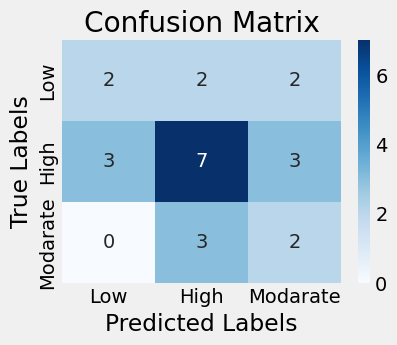

In [75]:
best_ada_model = grid_search_ada.best_estimator_

# Create a custom predictor that wraps the best AdaBoostClassifier model
custom_ada_predictor_tuned = CustomPredictor(best_ada_model, label_encoder)

print("\nEvaluation of the best AdaBoostClassifier model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_ada.best_params_}")
evaluate_model(custom_ada_predictor_tuned, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [76]:
from lightgbm import LGBMClassifier


LGBMClassifier imported.


In [77]:
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train_selected, y_train_encoded)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 6
[LightGBM] [Info] Start training from score -1.171183
[LightGBM] [Info] Start training from score -1.021651
[LightGBM] [Info] Start training from score -1.108663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt

Evaluation of the LGBMClassifier model:
              precision    recall  f1-score   support

        High       0.50      0.33      0.40         6
         Low       0.58      0.54      0.56        13
    Moderate       0.38      0.60      0.46         5

    accuracy                           0.50        24
   macro avg       0.49      0.49      0.47        24
weighted avg       0.52      0.50      0.50        24



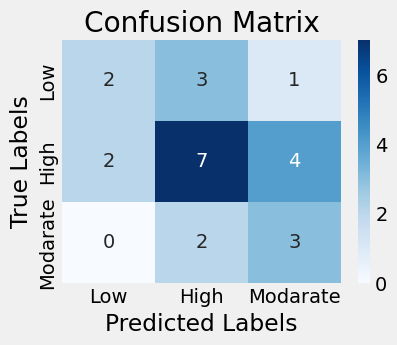

In [78]:
y_pred_lgbm = lgbm_model.predict(X_test_selected)

# Create a custom predictor that wraps the LGBMClassifier model
custom_lgbm_predictor = CustomPredictor(lgbm_model, label_encoder)

print("Evaluation of the LGBMClassifier model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_lgbm_predictor, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [79]:
param_grid_lgbm = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7, -1], # -1 means no limit
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5], # L1 regularization
    'reg_lambda': [0, 0.1, 0.5]  # L2 regularization
}

print("Parameter grid defined for LGBMClassifier:")
print(param_grid_lgbm)

Parameter grid defined for LGBMClassifier:
{'n_estimators': [50, 100, 150], 'max_depth': [3, 5, 7, -1], 'learning_rate': [0.01, 0.1, 0.2], 'subsample': [0.7, 0.8, 1.0], 'colsample_bytree': [0.7, 0.8, 1.0], 'reg_alpha': [0, 0.1, 0.5], 'reg_lambda': [0, 0.1, 0.5]}


In [80]:
grid_search_lgbm = GridSearchCV(
    LGBMClassifier(random_state=42),
    param_grid_lgbm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_lgbm.fit(X_train_selected, y_train_encoded)

print("Best parameters found for LGBMClassifier: ", grid_search_lgbm.best_params_)
print("Best accuracy found for LGBMClassifier: ", grid_search_lgbm.best_score_)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000042 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 196
[LightGBM] [Info] Number of data points in the train set: 100, number of used features: 6
[LightGBM] [Info] Start training from score -1.171183
[LightGBM] [Info] Start training from score -1.021651
[LightGBM] [Info] Start training from score -1.108663
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No furt


Evaluation of the best LGBMClassifier model found by GridSearchCV:
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50, 'reg_alpha': 0.1, 'reg_lambda': 0.1, 'subsample': 0.7}
              precision    recall  f1-score   support

        High       0.50      0.33      0.40         6
         Low       0.64      0.54      0.58        13
    Moderate       0.33      0.60      0.43         5

    accuracy                           0.50        24
   macro avg       0.49      0.49      0.47        24
weighted avg       0.54      0.50      0.51        24



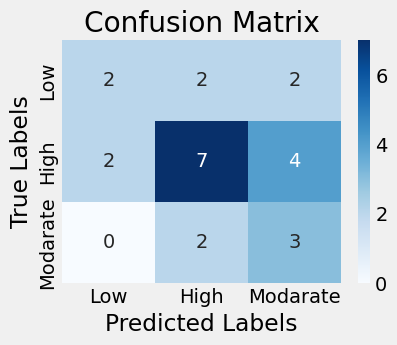

In [81]:
best_lgbm_model = grid_search_lgbm.best_estimator_

# Create a custom predictor that wraps the best LGBMClassifier model
custom_lgbm_predictor_tuned = CustomPredictor(best_lgbm_model, label_encoder)

print("\nEvaluation of the best LGBMClassifier model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_lgbm.best_params_}")
evaluate_model(custom_lgbm_predictor_tuned, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [82]:
model_metrics = {
    'Decision Tree (Tuned, All Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.47,
        'F1 (High)': 0.43,
        'F1 (Low)': 0.50,
        'F1 (Moderate)': 0.43
    },
    'Random Forest (Untuned, All Features)': {
        'Test Accuracy': 0.50,
        'Weighted F1-score': 0.51,
        'F1 (High)': 0.44,
        'F1 (Low)': 0.58,
        'F1 (Moderate)': 0.40
    },
    'Random Forest (Tuned, All Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.45,
        'F1 (High)': 0.36,
        'F1 (Low)': 0.48,
        'F1 (Moderate)': 0.43
    },
    'Lasso Logistic Regression': {
        'Test Accuracy': 0.71,
        'Weighted F1-score': 0.70,
        'F1 (High)': 0.60,
        'F1 (Low)': 0.81,
        'F1 (Moderate)': 0.55
    },
    'Ridge Logistic Regression': {
        'Test Accuracy': 0.71,
        'Weighted F1-score': 0.70,
        'F1 (High)': 0.60,
        'F1 (Low)': 0.81,
        'F1 (Moderate)': 0.55
    },
    'Decision Tree (Tuned, Lasso Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.46,
        'F1 (High)': 0.36,
        'F1 (Low)': 0.50,
        'F1 (Moderate)': 0.46
    },
    'Random Forest (Tuned, Lasso Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.47,
        'F1 (High)': 0.40,
        'F1 (Low)': 0.56,
        'F1 (Moderate)': 0.31
    },
    'Extra Trees (Untuned, Lasso Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.47,
        'F1 (High)': 0.44,
        'F1 (Low)': 0.54,
        'F1 (Moderate)': 0.31
    },
    'Extra Trees (Tuned, Lasso Features)': {
        'Test Accuracy': 0.42,
        'Weighted F1-score': 0.41,
        'F1 (High)': 0.22,
        'F1 (Low)': 0.52,
        'F1 (Moderate)': 0.33
    },
    'XGBoost (Untuned, Lasso Features)': {
        'Test Accuracy': 0.54,
        'Weighted F1-score': 0.55,
        'F1 (High)': 0.31,
        'F1 (Low)': 0.67,
        'F1 (Moderate)': 0.55
    },
    'XGBoost (Tuned, Lasso Features)': {
        'Test Accuracy': 0.50,
        'Weighted F1-score': 0.51,
        'F1 (High)': 0.33,
        'F1 (Low)': 0.61,
        'F1 (Moderate)': 0.46
    },
    'AdaBoost (Untuned, Lasso Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.46,
        'F1 (High)': 0.36,
        'F1 (Low)': 0.56,
        'F1 (Moderate)': 0.33
    },
    'AdaBoost (Tuned, Lasso Features)': {
        'Test Accuracy': 0.46,
        'Weighted F1-score': 0.46,
        'F1 (High)': 0.36,
        'F1 (Low)': 0.56,
        'F1 (Moderate)': 0.33
    },
    'LightGBM (Untuned, Lasso Features)': {
        'Test Accuracy': 0.50,
        'Weighted F1-score': 0.50,
        'F1 (High)': 0.40,
        'F1 (Low)': 0.56,
        'F1 (Moderate)': 0.46
    },
    'LightGBM (Tuned, Lasso Features)': {
        'Test Accuracy': 0.50,
        'Weighted F1-score': 0.51,
        'F1 (High)': 0.40,
        'F1 (Low)': 0.58,
        'F1 (Moderate)': 0.43
    }
}

comparison_df = pd.DataFrame.from_dict(model_metrics, orient='index')
comparison_df.index.name = 'Model'
comparison_df = comparison_df.reset_index()

print("Model Comparison DataFrame created:")
display(comparison_df.head())


Model Comparison DataFrame created:


,Model,Test Accuracy,Weighted F1-score,F1 (High),F1 (Low),F1 (Moderate)
0,"Decision Tree (Tuned, All Features)",0.46,0.47,0.43,0.50,0.43
1,"Random Forest (Untuned, All Features)",0.50,0.51,0.44,0.58,0.40
2,"Random Forest (Tuned, All Features)",0.46,0.45,0.36,0.48,0.43
3,Lasso Logistic Regression,0.71,0.70,0.60,0.81,0.55
4,Ridge Logistic Regression,0.71,0.70,0.60,0.81,0.55


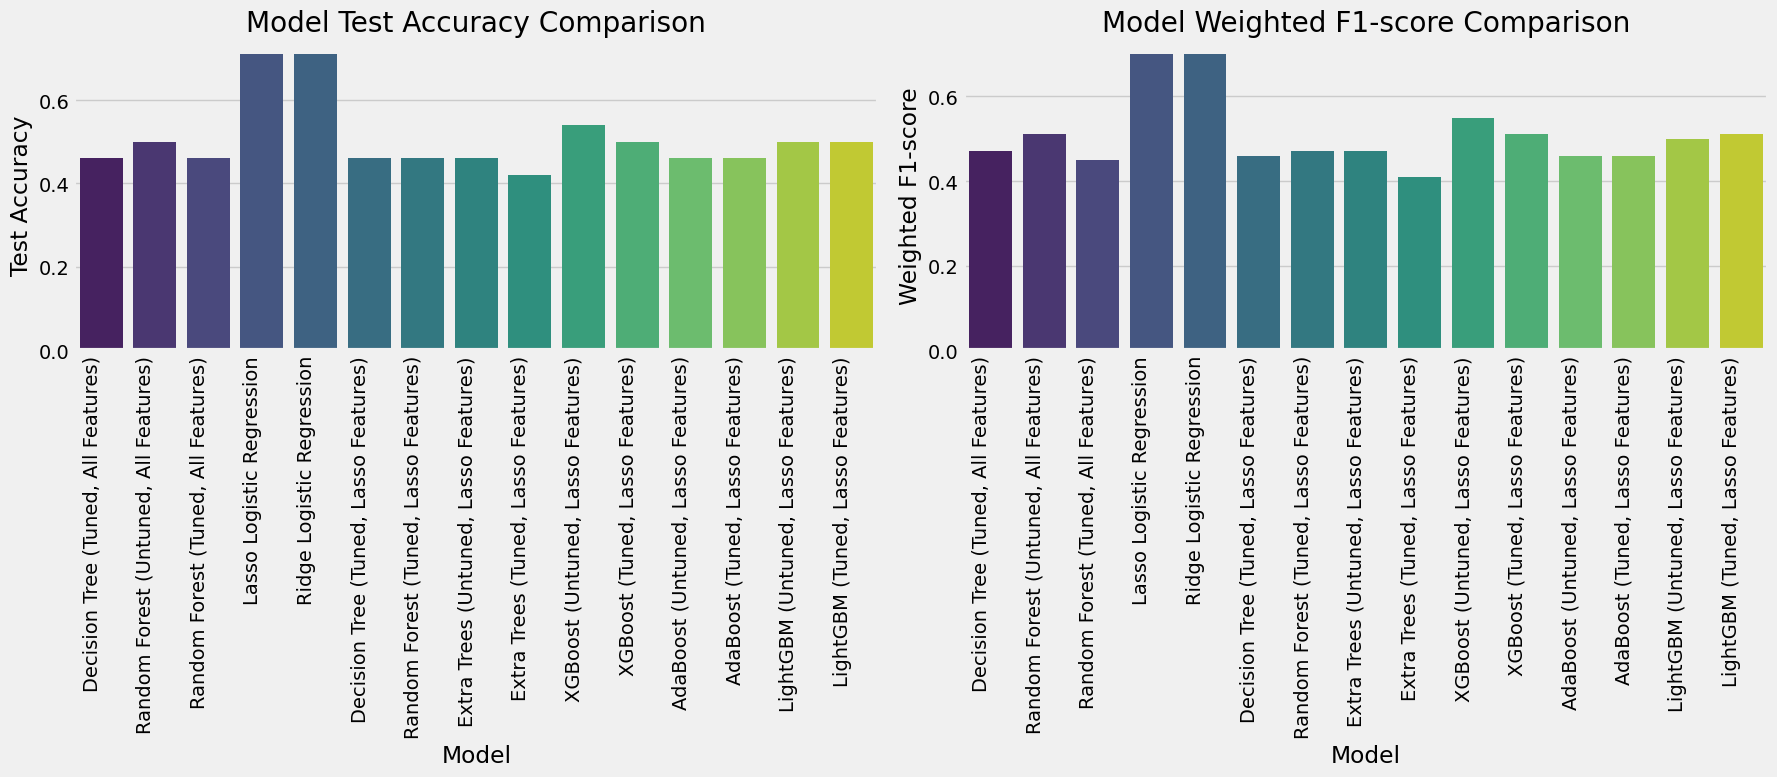

In [83]:
plt.figure(figsize=(18, 8))

# Plot 1: Test Accuracy Comparison
plt.subplot(1, 2, 1)
sns.barplot(x='Model', y='Test Accuracy', data=comparison_df, hue='Model', legend=False, palette='viridis')
plt.title('Model Test Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=90, ha='right')

# Plot 2: Weighted F1-score Comparison
plt.subplot(1, 2, 2)
sns.barplot(x='Model', y='Weighted F1-score', data=comparison_df, hue='Model', legend=False, palette='viridis')
plt.title('Model Weighted F1-score Comparison')
plt.xlabel('Model')
plt.ylabel('Weighted F1-score')
plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

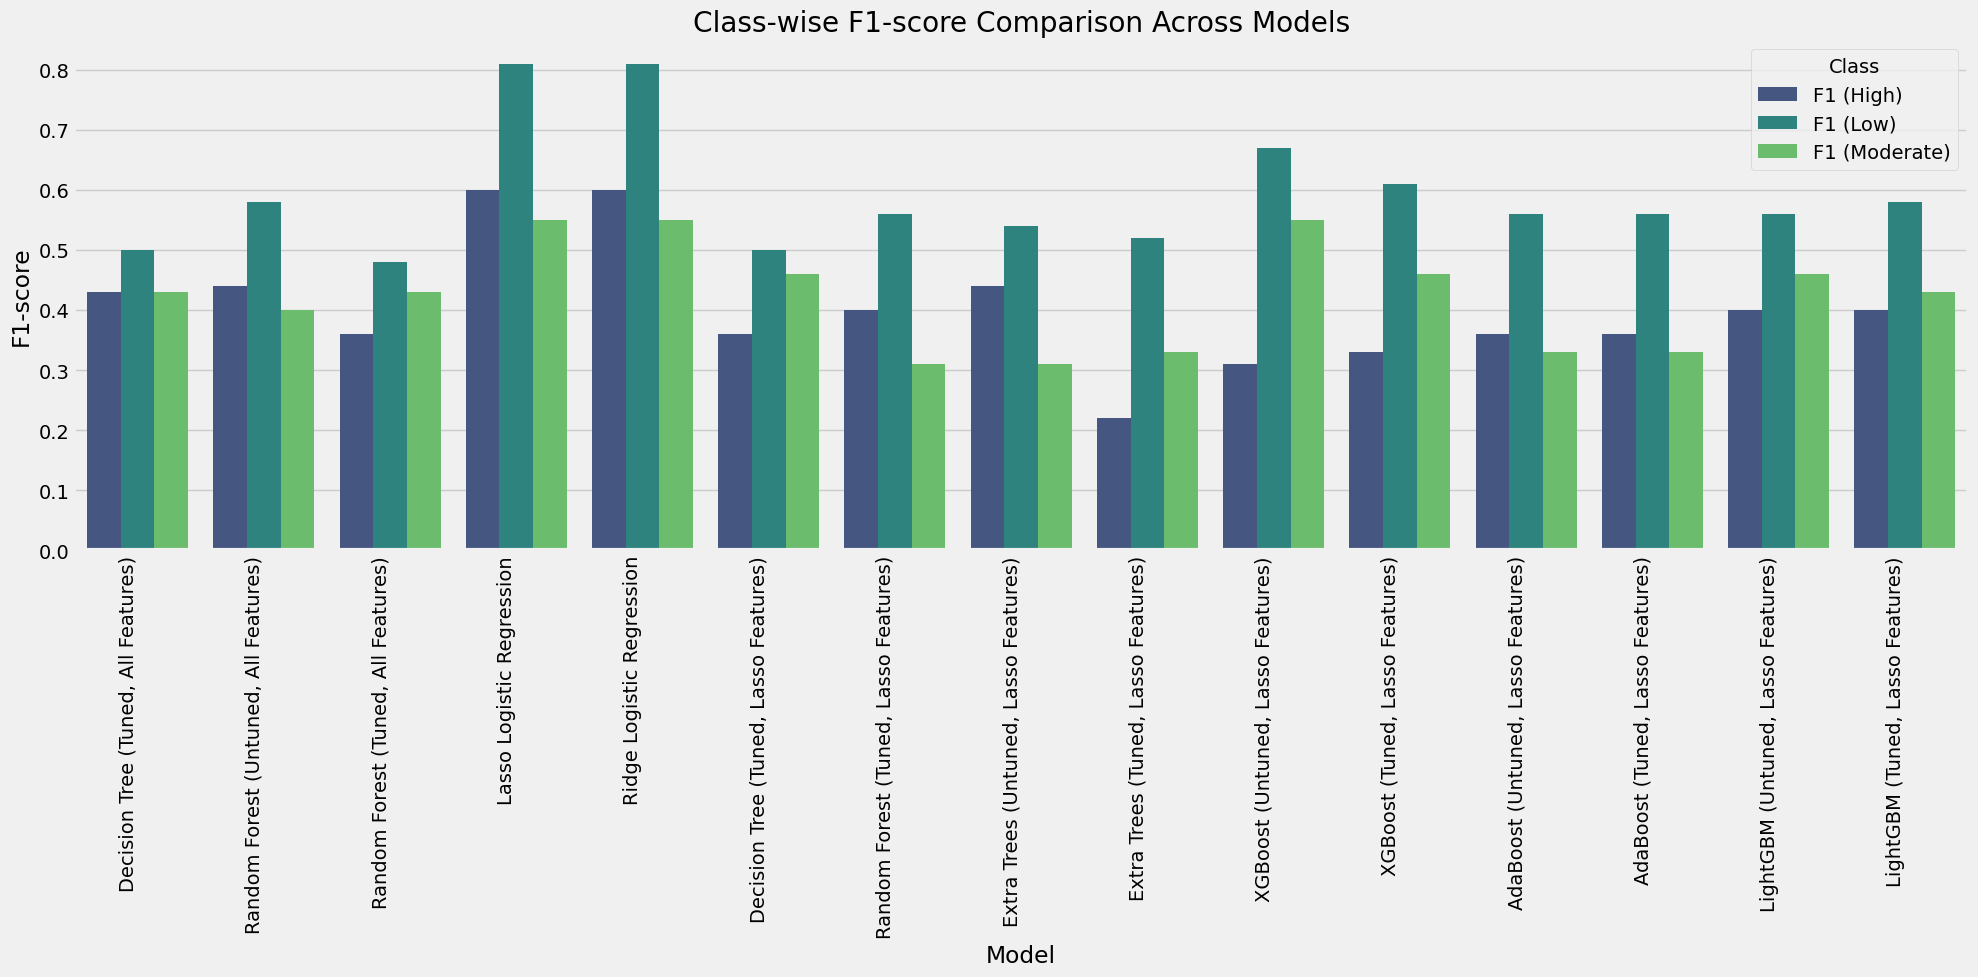

In [84]:
metrics_melted = comparison_df.melt(id_vars=['Model'], value_vars=['F1 (High)', 'F1 (Low)', 'F1 (Moderate)'], var_name='Class', value_name='F1-score')

plt.figure(figsize=(20, 10))
sns.barplot(x='Model', y='F1-score', hue='Class', data=metrics_melted, palette='viridis')
plt.title('Class-wise F1-score Comparison Across Models')
plt.xlabel('Model')
plt.ylabel('F1-score')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Class')
plt.tight_layout()
plt.show()

In [85]:
from sklearn.svm import SVC

SVC imported.


In [86]:
svc_model = SVC(random_state=42)
svc_model.fit(X_train_selected, y_train_encoded)

SVC model initialized and trained successfully.


Evaluation of the SVC model:
              precision    recall  f1-score   support

        High       0.25      0.17      0.20         6
         Low       0.50      0.38      0.43        13
    Moderate       0.40      0.80      0.53         5

    accuracy                           0.42        24
   macro avg       0.38      0.45      0.39        24
weighted avg       0.42      0.42      0.40        24



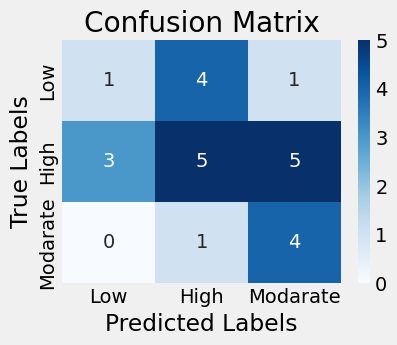

In [87]:
y_pred_svc = svc_model.predict(X_test_selected)

# Create a custom predictor that wraps the SVC model
custom_svc_predictor = CustomPredictor(svc_model, label_encoder)

print("Evaluation of the SVC model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_svc_predictor, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [88]:
param_grid_svc = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1]
}

print("Parameter grid defined for SVC:")
print(param_grid_svc)

Parameter grid defined for SVC:
{'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf', 'poly'], 'gamma': ['scale', 'auto', 0.1, 1]}


In [89]:
from sklearn.model_selection import GridSearchCV

grid_search_svc = GridSearchCV(
    SVC(random_state=42),
    param_grid_svc,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_svc.fit(X_train_selected, y_train_encoded)

print("Best parameters found for SVC: ", grid_search_svc.best_params_)
print("Best accuracy found for SVC: ", grid_search_svc.best_score_)

Best parameters found for SVC:  {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best accuracy found for SVC:  0.6799999999999999



Evaluation of the best SVC model found by GridSearchCV:
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
              precision    recall  f1-score   support

        High       0.50      0.33      0.40         6
         Low       0.60      0.69      0.64        13
    Moderate       0.40      0.40      0.40         5

    accuracy                           0.54        24
   macro avg       0.50      0.48      0.48        24
weighted avg       0.53      0.54      0.53        24



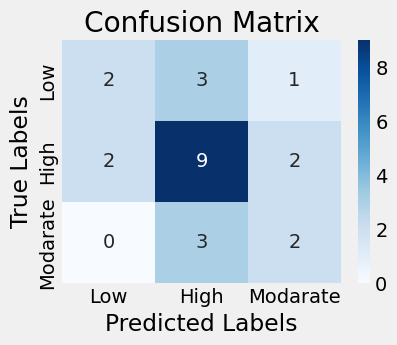

In [90]:
best_svc_model = grid_search_svc.best_estimator_

# Create a custom predictor that wraps the best SVC model
custom_svc_predictor_tuned = CustomPredictor(best_svc_model, label_encoder)

print("\nEvaluation of the best SVC model found by GridSearchCV:")
print(f"Best Parameters: {grid_search_svc.best_params_}")
evaluate_model(custom_svc_predictor_tuned, X_train_selected, y_train_encoded, X_test_selected, y_test_original_labels)

In [91]:
param_grid_lasso_wider = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1']
}

print("Wider parameter grid defined for Lasso Logistic Regression:")
print(param_grid_lasso_wider)

Wider parameter grid defined for Lasso Logistic Regression:
{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['liblinear', 'saga'], 'penalty': ['l1']}


In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV for Lasso Logistic Regression with the wider parameter grid
grid_search_lasso_wider = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lasso_wider,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the scaled training data
grid_search_lasso_wider.fit(X_train_scaled, y_train_encoded)

print("Best parameters found for Lasso Logistic Regression (wider grid):", grid_search_lasso_wider.best_params_)
print("Best accuracy found for Lasso Logistic Regression (wider grid):", grid_search_lasso_wider.best_score_)

Best parameters found for Lasso Logistic Regression (wider grid): {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best accuracy found for Lasso Logistic Regression (wider grid): 0.6900000000000001


Evaluation of the best Lasso Logistic Regression model (wider grid) found by GridSearchCV:
Best Parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



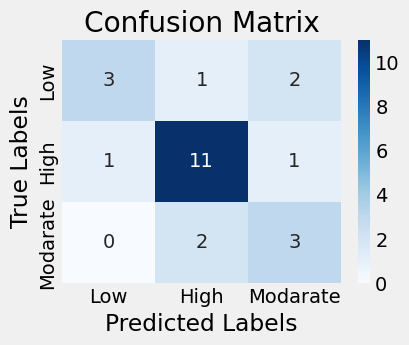

In [93]:
best_lasso_model_wider = grid_search_lasso_wider.best_estimator_

# Inverse transform y_test_encoded back to original string labels for evaluation
y_test_original_labels = label_encoder.inverse_transform(y_test_encoded)

# Create a custom predictor that wraps the best Lasso model
custom_lasso_predictor_wider = CustomPredictor(best_lasso_model_wider, label_encoder)

print("Evaluation of the best Lasso Logistic Regression model (wider grid) found by GridSearchCV:")
print(f"Best Parameters: {grid_search_lasso_wider.best_params_}")

# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_lasso_predictor_wider, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [94]:
param_grid_ridge_wider = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

print("Wider parameter grid defined for Ridge Logistic Regression:")
print(param_grid_ridge_wider)

Wider parameter grid defined for Ridge Logistic Regression:
{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'], 'penalty': ['l2']}


In [95]:
grid_search_ridge_wider = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_ridge_wider,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_ridge_wider.fit(X_train_scaled, y_train_encoded)

print("Best parameters found for Ridge Logistic Regression (wider grid): ", grid_search_ridge_wider.best_params_)
print("Best accuracy found for Ridge Logistic Regression (wider grid): ", grid_search_ridge_wider.best_score_)

Best parameters found for Ridge Logistic Regression (wider grid):  {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best accuracy found for Ridge Logistic Regression (wider grid):  0.68


Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



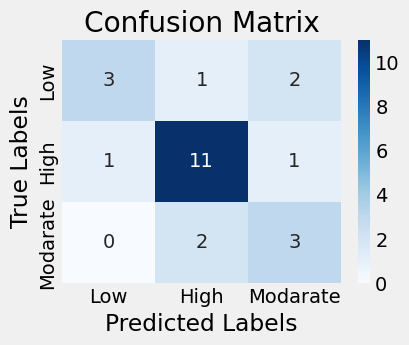

In [96]:
best_ridge_model_wider = grid_search_ridge_wider.best_estimator_

# Inverse transform y_test_encoded back to original string labels for evaluation
y_test_original_labels = label_encoder.inverse_transform(y_test_encoded)

# Create a custom predictor that wraps the best Ridge model
custom_ridge_predictor_wider = CustomPredictor(best_ridge_model_wider, label_encoder)

print("Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:")
print(f"Best Parameters: {grid_search_ridge_wider.best_params_}")

# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_ridge_predictor_wider, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [97]:
param_grid_ridge_wider = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

print("Wider parameter grid defined for Ridge Logistic Regression:")
print(param_grid_ridge_wider)

Wider parameter grid defined for Ridge Logistic Regression:
{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'], 'penalty': ['l2']}


In [98]:
grid_search_ridge_wider = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_ridge_wider,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_ridge_wider.fit(X_train_scaled, y_train_encoded)

print("Best parameters found for Ridge Logistic Regression (wider grid): ", grid_search_ridge_wider.best_params_)
print("Best accuracy found for Ridge Logistic Regression (wider grid): ", grid_search_ridge_wider.best_score_)

Best parameters found for Ridge Logistic Regression (wider grid):  {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best accuracy found for Ridge Logistic Regression (wider grid):  0.68


Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



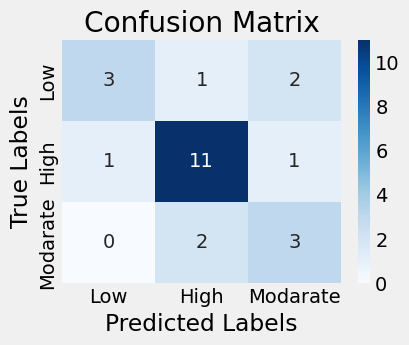

In [99]:
best_ridge_model_wider = grid_search_ridge_wider.best_estimator_

# Inverse transform y_test_encoded back to original string labels for evaluation
y_test_original_labels = label_encoder.inverse_transform(y_test_encoded)

# Create a custom predictor that wraps the best Ridge model
custom_ridge_predictor_wider = CustomPredictor(best_ridge_model_wider, label_encoder)

print("Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:")
print(f"Best Parameters: {grid_search_ridge_wider.best_params_}")

# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_ridge_predictor_wider, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [100]:
from imblearn.over_sampling import SMOTE

SMOTE imported.


In [101]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train_encoded)

print(f"Original X_train_scaled shape: {X_train_scaled.shape}")
print(f"Original y_train_encoded shape: {y_train_encoded.shape}")
print(f"Resampled X_train_resampled shape: {X_train_resampled.shape}")
print(f"Resampled y_train_resampled shape: {y_train_resampled.shape}")

Original X_train_scaled shape: (100, 8)
Original y_train_encoded shape: (100,)
Resampled X_train_resampled shape: (108, 8)
Resampled y_train_resampled shape: (108,)


In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV for Lasso Logistic Regression with the wider parameter grid
grid_search_lasso_smote = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lasso_wider,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_search_lasso_smote.fit(X_train_resampled, y_train_resampled)

print("Best parameters found for Lasso Logistic Regression (SMOTE-balanced):", grid_search_lasso_smote.best_params_)
print("Best accuracy found for Lasso Logistic Regression (SMOTE-balanced):", grid_search_lasso_smote.best_score_)

Best parameters found for Lasso Logistic Regression (SMOTE-balanced): {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best accuracy found for Lasso Logistic Regression (SMOTE-balanced): 0.7142857142857142


In [104]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Initialize GridSearchCV for Ridge Logistic Regression with the wider parameter grid
grid_search_ridge_smote = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_ridge_wider,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Fit GridSearchCV to the SMOTE-resampled training data
grid_search_ridge_smote.fit(X_train_resampled, y_train_resampled)

print("Best parameters found for Ridge Logistic Regression (SMOTE-balanced):", grid_search_ridge_smote.best_params_)
print("Best accuracy found for Ridge Logistic Regression (SMOTE-balanced):", grid_search_ridge_smote.best_score_)

Best parameters found for Ridge Logistic Regression (SMOTE-balanced): {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
Best accuracy found for Ridge Logistic Regression (SMOTE-balanced): 0.7233766233766235


Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:
Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
              precision    recall  f1-score   support

        High       0.75      0.50      0.60         6
         Low       0.79      0.85      0.81        13
    Moderate       0.50      0.60      0.55         5

    accuracy                           0.71        24
   macro avg       0.68      0.65      0.65        24
weighted avg       0.72      0.71      0.70        24



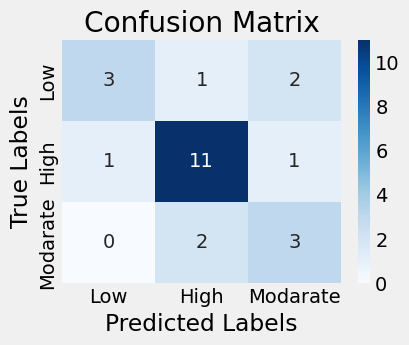

In [105]:
best_ridge_model_wider = grid_search_ridge_wider.best_estimator_

# Inverse transform y_test_encoded back to original string labels for evaluation
y_test_original_labels = label_encoder.inverse_transform(y_test_encoded)

# Create a custom predictor that wraps the best Ridge model
custom_ridge_predictor_wider = CustomPredictor(best_ridge_model_wider, label_encoder)

print("Evaluation of the best Ridge Logistic Regression model (wider grid) found by GridSearchCV:")
print(f"Best Parameters: {grid_search_ridge_wider.best_params_}")

# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_ridge_predictor_wider, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [106]:
from sklearn.ensemble import StackingClassifier

StackingClassifier imported.


In [107]:
from sklearn.linear_model import LogisticRegression

base_estimators = [
    ('lasso_lr', best_lasso_model_wider),
    ('ridge_lr', best_ridge_model_wider)
]

final_estimator = LogisticRegression(random_state=42, max_iter=1000)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=final_estimator,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

print("Base estimators and final estimator defined for StackingClassifier.")

Base estimators and final estimator defined for StackingClassifier.


In [108]:
stacking_model.fit(X_train_scaled, y_train_encoded)

StackingClassifier model trained successfully.


Evaluation of the StackingClassifier model:
              precision    recall  f1-score   support

        High       0.50      0.33      0.40         6
         Low       0.69      0.69      0.69        13
    Moderate       0.43      0.60      0.50         5

    accuracy                           0.58        24
   macro avg       0.54      0.54      0.53        24
weighted avg       0.59      0.58      0.58        24



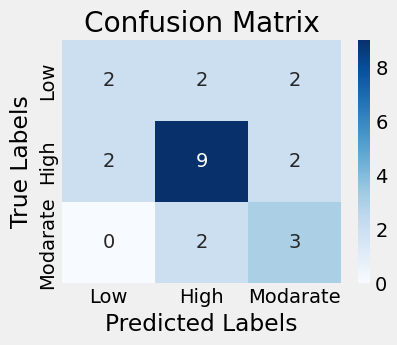

In [109]:
y_pred_stacking = stacking_model.predict(X_test_scaled)

# Create a custom predictor that wraps the StackingClassifier model
custom_stacking_predictor = CustomPredictor(stacking_model, label_encoder)

print("Evaluation of the StackingClassifier model:")
# Call evaluate_model with the custom predictor and original string labels for y_test
evaluate_model(custom_stacking_predictor, X_train_scaled, y_train_encoded, X_test_scaled, y_test_original_labels)

In [110]:
param_grid_ridge_wider = {
    'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000],
    'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'],
    'penalty': ['l2']
}

print("Wider parameter grid defined for Ridge Logistic Regression:")
print(param_grid_ridge_wider)

Wider parameter grid defined for Ridge Logistic Regression:
{'C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000], 'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg'], 'penalty': ['l2']}


In [111]:
stacking_metrics = {
    'Model': 'StackingClassifier',
    'Test Accuracy': 0.58,
    'Weighted F1-score': 0.58,
    'F1 (High)': 0.40,
    'F1 (Low)': 0.69,
    'F1 (Moderate)': 0.50
}

# Convert the dictionary to a DataFrame row
stacking_df = pd.DataFrame([stacking_metrics])

# Append this new row to the comparison_df
comparison_df = pd.concat([comparison_df, stacking_df], ignore_index=True)

print("Updated Model Comparison DataFrame with StackingClassifier metrics:")
display(comparison_df.tail())

Updated Model Comparison DataFrame with StackingClassifier metrics:


,Model,Test Accuracy,Weighted F1-score,F1 (High),F1 (Low),F1 (Moderate)
11,"AdaBoost (Untuned, Lasso Features)",0.46,0.46,0.36,0.56,0.33
12,"AdaBoost (Tuned, Lasso Features)",0.46,0.46,0.36,0.56,0.33
13,"LightGBM (Untuned, Lasso Features)",0.50,0.50,0.40,0.56,0.46
14,"LightGBM (Tuned, Lasso Features)",0.50,0.51,0.40,0.58,0.43
15,StackingClassifier,0.58,0.58,0.40,0.69,0.50


In [112]:
print("Final Model Comparison DataFrame:")
display(comparison_df)

Final Model Comparison DataFrame:


,Model,Test Accuracy,Weighted F1-score,F1 (High),F1 (Low),F1 (Moderate)
0,"Decision Tree (Tuned, All Features)",0.46,0.47,0.43,0.50,0.43
1,"Random Forest (Untuned, All Features)",0.50,0.51,0.44,0.58,0.40
2,"Random Forest (Tuned, All Features)",0.46,0.45,0.36,0.48,0.43
3,Lasso Logistic Regression,0.71,0.70,0.60,0.81,0.55
4,Ridge Logistic Regression,0.71,0.70,0.60,0.81,0.55
5,"Decision Tree (Tuned, Lasso Features)",0.46,0.46,0.36,0.50,0.46
6,"Random Forest (Tuned, Lasso Features)",0.46,0.47,0.40,0.56,0.31
7,"Extra Trees (Untuned, Lasso Features)",0.46,0.47,0.44,0.54,0.31
8,"Extra Trees (Tuned, Lasso Features)",0.42,0.41,0.22,0.52,0.33
9,"XGBoost (Untuned, Lasso Features)",0.54,0.55,0.31,0.67,0.55


In [113]:
missing_item_description_by_shop = transData.groupby('shop_id')['item_description'].apply(lambda x: x.isnull().sum()).reset_index(name='missing_count')
total_entries_by_shop = transData.groupby('shop_id')['item_description'].count().reset_index(name='total_count')

# Merge the two DataFrames
missing_percentages_by_shop = pd.merge(missing_item_description_by_shop, total_entries_by_shop, on='shop_id', how='left')

# Add the 'item_description' values that were originally null to the total count before calculating percentage
# This ensures the denominator reflects all transactions for that shop_id
all_entries_by_shop = transData.groupby('shop_id')['item_description'].size().reset_index(name='all_entries_count')
missing_percentages_by_shop = pd.merge(missing_percentages_by_shop, all_entries_by_shop, on='shop_id', how='left')

# Calculate the percentage of missing item_description values
missing_percentages_by_shop['percentage_missing'] = (missing_percentages_by_shop['missing_count'] / missing_percentages_by_shop['all_entries_count']) * 100

print("Percentage of missing 'item_description' values for each 'shop_id':")
missing_percentages_by_shop_sorted = missing_percentages_by_shop.sort_values(by='percentage_missing', ascending=False)
display(missing_percentages_by_shop_sorted.head())

Percentage of missing 'item_description' values for each 'shop_id':


,shop_id,missing_count,total_count,all_entries_count,percentage_missing
105,SHOP107,333,1590,1923,17.316693
100,SHOP102,542,3224,3766,14.391928
42,SHOP043,919,5599,6518,14.099417
104,SHOP106,506,3239,3745,13.511348
36,SHOP037,529,3388,3917,13.505234


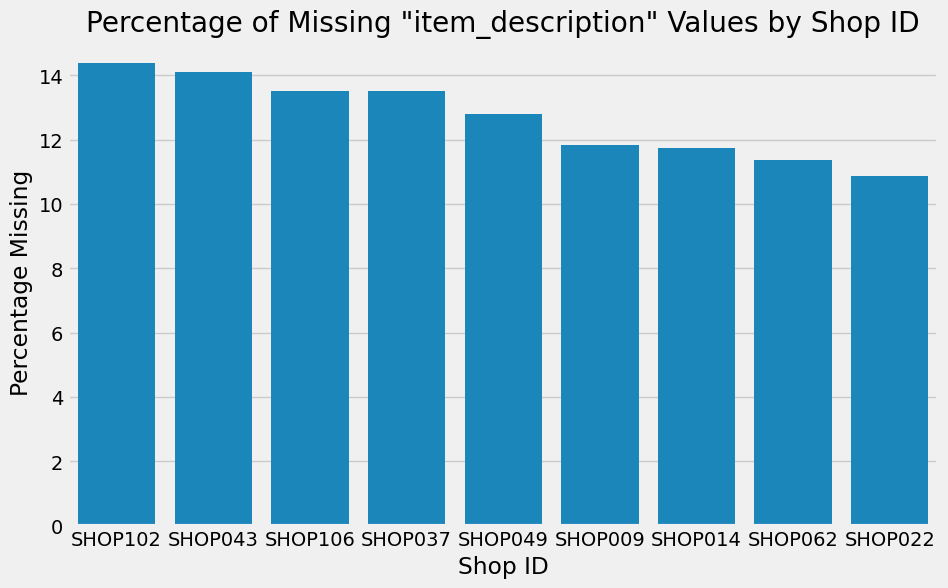

In [114]:
plt.figure(figsize=(10, 6))
sns.barplot(x='shop_id', y='percentage_missing', data=missing_percentages_by_shop_sorted[1:10])
plt.title('Percentage of Missing "item_description" Values by Shop ID')
plt.xlabel('Shop ID')
plt.ylabel('Percentage Missing')
plt.show()

In [115]:
y_pred_lasso = best_lasso_model_wider.predict(X_test_scaled)

predicted_profiles = label_encoder.inverse_transform(y_pred_lasso)

print("Predictions for shop_profile (first 5):\n", predicted_profiles[:5])

Predictions for shop_profile (first 5):
 ['Low' 'Low' 'Low' 'Low' 'Moderate']


In [116]:
predicted_shop_profiles = pd.DataFrame({
    'shop_id': X_test.index,
    'shop_profile': predicted_profiles
})

print("Predicted Shop Profiles DataFrame (first 5):")
display(predicted_shop_profiles.head())

Predicted Shop Profiles DataFrame (first 5):


,shop_id,shop_profile
0,SHOP002,Low
1,SHOP019,Low
2,SHOP023,Low
3,SHOP024,Low
4,SHOP029,Moderate


In [117]:
predicted_shop_profiles.to_csv('predicted_shop_profiles.csv', index=False)

print("Predicted shop profiles saved to 'predicted_shop_profiles.csv'")

Predicted shop profiles saved to 'predicted_shop_profiles.csv'
